# Notebook 03 — Analiza multivariată și modele avansate cu sentiment

**Proiect:** Modelarea și prognoza volatilității S&P 500 sub influența sentimentului din știrile financiare  
**Rolul notebook-ului:** testăm dacă sentimentul financiar adaugă informație predictivă pentru volatilitatea S&P 500, peste benchmark-urile univariate din Notebook 02.

## Target principal

În acest notebook, ținta principală este:

$$RV_{22,t}$$

adică volatilitatea realizată pe 22 de zile, notată în dataset ca `rv_22d`.

## Structura notebook-ului

1. Setup și încărcarea datelor  
2. Obiectivul analizei multivariate  
3. Pregătirea variabilelor, sentimentului și lagurilor  
4. Train/test split 70/30, fără shuffle  
5. Staționaritate și ordine de integrare  
6. Cointegrare și decizia VAR/VECM  
7. VAR, Granger, IRF, FEVD  
8. Efecte ARCH/GARCH în context multivariat  
9. HAR-RV și HAR-RV-X cu sentiment  
10. MLP fără sentiment vs. MLP cu sentiment  
11. RNN fără sentiment vs. RNN cu sentiment  
12. LSTM fără sentiment vs. LSTM cu sentiment  
13. Comparație finală, Diebold-Mariano și concluzii

## Întrebarea centrală

> Sentimentul financiar îmbunătățește prognoza volatilității S&P 500?

## 0. Setup și importuri

Notebook-ul pornește de la datasetul final produs în Notebook 01:

`data/processed/sp500_sentiment_daily.parquet`

In [2]:
# ------------------------------------------------------------
# 0. SETUP
# ------------------------------------------------------------

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# Statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# ML
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional: ARCH/GARCH
try:
    from arch import arch_model
    from arch.unitroot import PhillipsPerron
    ARCH_OK = True
except Exception:
    ARCH_OK = False
    print("Pachetul 'arch' nu este disponibil. Instalează cu: pip install arch")

# Optional: TensorFlow/Keras pentru RNN/LSTM
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_OK = True
    tf.random.set_seed(42)
except Exception:
    TF_OK = False
    print("TensorFlow nu este disponibil. RNN/LSTM vor fi sărite. Instalează cu: pip install tensorflow")

np.random.seed(42)

# Paths
PROJECT_ROOT = Path('.')
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'sp500_sentiment_daily.parquet'
FIG_DIR = PROJECT_ROOT / 'data' / 'figures' / 'notebook_03'
TABLE_DIR = PROJECT_ROOT / 'data' / 'tables' / 'notebook_03'
MODEL_DIR = PROJECT_ROOT / 'data' / 'models' / 'notebook_03'

for p in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Config
SPLIT_RATIO = 0.70
TARGET = 'rv_22d'
PLOT_WINDOW = 60
MAX_VAR_LAGS = 10
ML_LAGS = [1, 2, 3, 5, 10, 22]
SEQ_LEN = 10
EPOCHS = 250
BATCH_SIZE = 32
DL_PATIENCE = 25
DL_LR_PATIENCE = 8

plt.rcParams.update({
    'figure.figsize': (13, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

print('Setup OK')
print('ARCH_OK:', ARCH_OK)
print('TF_OK:', TF_OK)
print('Target principal:', TARGET)


Setup OK
ARCH_OK: True
TF_OK: True
Target principal: rv_22d


## 1. Încărcarea datelor și construirea variabilelor de bază

Folosim datele financiare și scorurile de sentiment produse în Notebook 01. În acest notebook ne concentrăm pe `rv_22d` ca proxy principal pentru volatilitate.

In [3]:
# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Nu găsesc {DATA_PATH}. Rulează Notebook 01 sau modifică DATA_PATH."
    )

df = pd.read_parquet(DATA_PATH)

if not isinstance(df.index, pd.DatetimeIndex):
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
    else:
        df.index = pd.to_datetime(df.index)

df = df.sort_index()
df.index.freq = None

print(f"Dataset: {df.shape[0]:,} observații, {df.shape[1]} coloane")
print(f"Perioada: {df.index.min().date()} → {df.index.max().date()}")
print(list(df.columns[:25]))
df.head()

Dataset: 1,758 observații, 40 coloane
Perioada: 2018-01-04 → 2024-12-30
['close', 'adj_close', 'volume', 'vix', 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'S_sum', 'S_mean', 'S_median', 'n_articles', 'n_pos', 'n_neg', 'n_neu', 'S_pos_ratio', 'S_neg_ratio', 'S_polarity', 'S_sum_business', 'S_mean_business', 'n_business', 'S_sum_washington', 'S_mean_washington', 'n_washington']


,close,adj_close,volume,vix,r_t,r_t_sq,abs_r_t,rv_5d,rv_22d,S_sum,...,n_specialsections,S_sum_obits,S_mean_obits,n_obits,S_sum_express,S_mean_express,n_express,S_sum_lag1,S_mean_lag1,S_polarity_lag1
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-04,2723.989990,2723.989990,3697340000,9.22,0.402054,0.161648,0.402054,NaN,NaN,0.259622,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.530828,-0.197904,-0.181818
2018-01-05,2743.149902,2743.149902,3239280000,9.22,0.700915,0.491281,0.700915,NaN,NaN,0.124794,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.259622,0.025962,0.000000
2018-01-08,2747.709961,2747.709961,3246160000,9.52,0.166096,0.027588,0.166096,NaN,NaN,-7.764763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.124794,0.009600,0.000000
2018-01-09,2751.290039,2751.290039,3467460000,10.08,0.130208,0.016954,0.130208,1.050864,NaN,-0.857979,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-7.764763,-0.456751,-0.529412
2018-01-10,2748.229980,2748.229980,3579900000,9.82,-0.111285,0.012384,0.111285,0.842529,NaN,-4.869733,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.857979,-0.077998,-0.090909


In [4]:
# ------------------------------------------------------------
# 1.1 Serii financiare de bază
# ------------------------------------------------------------

work = df.copy()

# Preț
if 'adj_close' in work.columns:
    price_col = 'adj_close'
elif 'close' in work.columns:
    price_col = 'close'
else:
    raise ValueError("Datasetul trebuie să conțină 'adj_close' sau 'close'.")

# Randamente și volatilitate proxy
if 'r_t' not in work.columns:
    work['r_t'] = 100 * np.log(work[price_col]).diff()
if 'r_t_sq' not in work.columns:
    work['r_t_sq'] = work['r_t'] ** 2
if 'abs_r_t' not in work.columns:
    work['abs_r_t'] = work['r_t'].abs()
if 'rv_5d' not in work.columns:
    work['rv_5d'] = work['r_t'].rolling(5).std()
if 'rv_22d' not in work.columns:
    work['rv_22d'] = work['r_t'].rolling(22).std()

# VIX și transformări, dacă există
if 'vix' not in work.columns:
    possible_vix_cols = [c for c in work.columns if 'vix' in c.lower()]
    if len(possible_vix_cols) > 0:
        work['vix'] = work[possible_vix_cols[0]]

if 'vix' in work.columns:
    work['log_vix'] = np.log(work['vix'].clip(lower=1e-6))
    work['d_vix'] = work['vix'].diff()
    work['d_log_vix'] = work['log_vix'].diff()

work['log_price'] = np.log(work[price_col].clip(lower=1e-6))

print('Coloane financiare pregătite.')
work[[price_col, 'r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d']].describe().T.round(4)

Coloane financiare pregătite.


,count,mean,std,min,25%,50%,75%,max
adj_close,1758.0,3851.3997,917.7178,2237.3999,2937.8575,3908.8550,4449.9849,6090.2700
r_t,1758.0,0.0443,1.2478,-12.7652,-0.4614,0.0873,0.6750,8.9683
r_t_sq,1758.0,1.5582,6.2844,0.0000,0.0522,0.3326,1.1984,162.9508
abs_r_t,1758.0,0.8199,0.9415,0.0006,0.2285,0.5767,1.0947,12.7652
rv_5d,1755.0,2.1993,1.7213,0.2792,1.1979,1.7967,2.6726,20.0982
rv_22d,1738.0,4.9006,3.2390,1.5587,3.0598,3.9921,5.9198,27.6406


## 2. Obiectivul analizei multivariate

Notebook 02 a arătat că:

- randamentele sunt greu de prezis;
- volatilitatea este persistentă;
- efectele ARCH/GARCH sunt puternice.

În Notebook 03 verificăm dacă sentimentul financiar adaugă informație peste aceste regularități.

Variabila țintă principală este:

$$RV_{22,t}$$

Modelele vor fi comparate în perechi:

- fără sentiment;
- cu sentiment.

## 3. Pregătirea variabilelor de sentiment

Construim indicatori utili:

- polaritate medie/totală;
- număr de articole;
- pondere de știri negative;
- pondere de știri pozitive.

Toate variabilele de sentiment vor fi folosite cu lag, pentru a evita leakage.

In [5]:
# ------------------------------------------------------------
# 3. SENTIMENT VARIABLES
# ------------------------------------------------------------

# Creăm neg_share / pos_share dacă avem număr de știri pozitive/negative
if 'neg_share' not in work.columns and {'n_neg', 'n_articles'}.issubset(work.columns):
    work['neg_share'] = work['n_neg'] / work['n_articles'].replace(0, np.nan)

if 'pos_share' not in work.columns and {'n_pos', 'n_articles'}.issubset(work.columns):
    work['pos_share'] = work['n_pos'] / work['n_articles'].replace(0, np.nan)

# Dacă nu există n_pos/n_neg dar există label counts alternative, încercăm să detectăm coloane asemănătoare
# Această secțiune este defensivă; nu afectează dacă Notebook 01 a produs deja coloanele standard.

candidate_sentiment_cols = [
    'S_sum', 'S_mean', 'S_polarity',
    'n_articles', 'n_pos', 'n_neg', 'n_neu',
    'neg_share', 'pos_share',
    'prob_positive_mean', 'prob_negative_mean', 'prob_neutral_mean'
]

sentiment_cols = [c for c in candidate_sentiment_cols if c in work.columns]

print('Variabile sentiment disponibile:')
for c in sentiment_cols:
    print(' -', c)

if len(sentiment_cols) == 0:
    raise ValueError("Nu am găsit variabile de sentiment. Verifică output-ul Notebook 01.")

work[sentiment_cols].describe().T.round(4)

Variabile sentiment disponibile:
 - S_sum
 - S_mean
 - S_polarity
 - n_articles
 - n_pos
 - n_neg
 - n_neu
 - neg_share
 - pos_share


,count,mean,std,min,25%,50%,75%,max
S_sum,1758.0,-3.8872,2.7511,-19.2892,-5.5714,-3.7081,-1.9949,5.3739
S_mean,1758.0,-0.2930,0.1888,-0.8692,-0.4190,-0.3021,-0.1667,0.5956
S_polarity,1758.0,-0.3356,0.2265,-1.0000,-0.5000,-0.3500,-0.1818,0.7778
n_articles,1758.0,13.2662,4.4014,1.0000,10.0000,13.0000,16.0000,35.0000
n_pos,1758.0,1.8840,1.4987,0.0000,1.0000,2.0000,3.0000,9.0000
n_neg,1758.0,6.3390,2.8650,0.0000,4.0000,6.0000,8.0000,22.0000
n_neu,1758.0,5.0432,2.6907,0.0000,3.0000,5.0000,6.0000,25.0000
neg_share,1758.0,0.4794,0.1562,0.0000,0.3750,0.4762,0.5833,1.0000
pos_share,1758.0,0.1438,0.1120,0.0000,0.0667,0.1250,0.2105,0.7778


In [6]:
# ------------------------------------------------------------
# 3.1 LAGURI PENTRU SENTIMENT ȘI FINANCIAL FEATURES
# ------------------------------------------------------------

# Variabile financiare candidate pentru ML / HAR / modele predictive
financial_cols = ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d']
if 'vix' in work.columns:
    financial_cols.append('vix')
if 'd_vix' in work.columns:
    financial_cols.append('d_vix')

# Pentru sentiment, folosim un subset interpretabil și robust
preferred_sentiment_cols = [c for c in ['S_polarity', 'S_mean', 'S_sum', 'neg_share', 'pos_share', 'n_articles'] if c in work.columns]
if len(preferred_sentiment_cols) == 0:
    preferred_sentiment_cols = sentiment_cols[:min(4, len(sentiment_cols))]

# Laguri pentru ML
lagged_cols = []
for col in financial_cols + preferred_sentiment_cols:
    for lag in ML_LAGS:
        new_col = f'{col}_lag{lag}'
        work[new_col] = work[col].shift(lag)
        lagged_cols.append(new_col)

# HAR-RV features
work['rv_lag1'] = work[TARGET].shift(1)
work['rv_week'] = work[TARGET].rolling(5).mean().shift(1)
work['rv_month'] = work[TARGET].rolling(22).mean().shift(1)

# Target next-day este valoarea curentă, iar features sunt lagged.
# Astfel X_{t-1}, X_{t-2}, ... prezic RV_t.

print('Financial cols:', financial_cols)
print('Preferred sentiment cols:', preferred_sentiment_cols)
print('Nr. lagged cols:', len(lagged_cols))

Financial cols: ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'vix', 'd_vix']
Preferred sentiment cols: ['S_polarity', 'S_mean', 'S_sum', 'neg_share', 'pos_share', 'n_articles']
Nr. lagged cols: 78


## 4. Train/test split 70/30

Folosim același principiu ca în articolul de referință: split cronologic 70% train / 30% test, fără shuffle.

Target: rv_22d
Train: 2018-02-02 → 2022-11-30 | n=1,216
Test:  2022-12-01 → 2024-12-30 | n=522
Split date: 2022-12-01


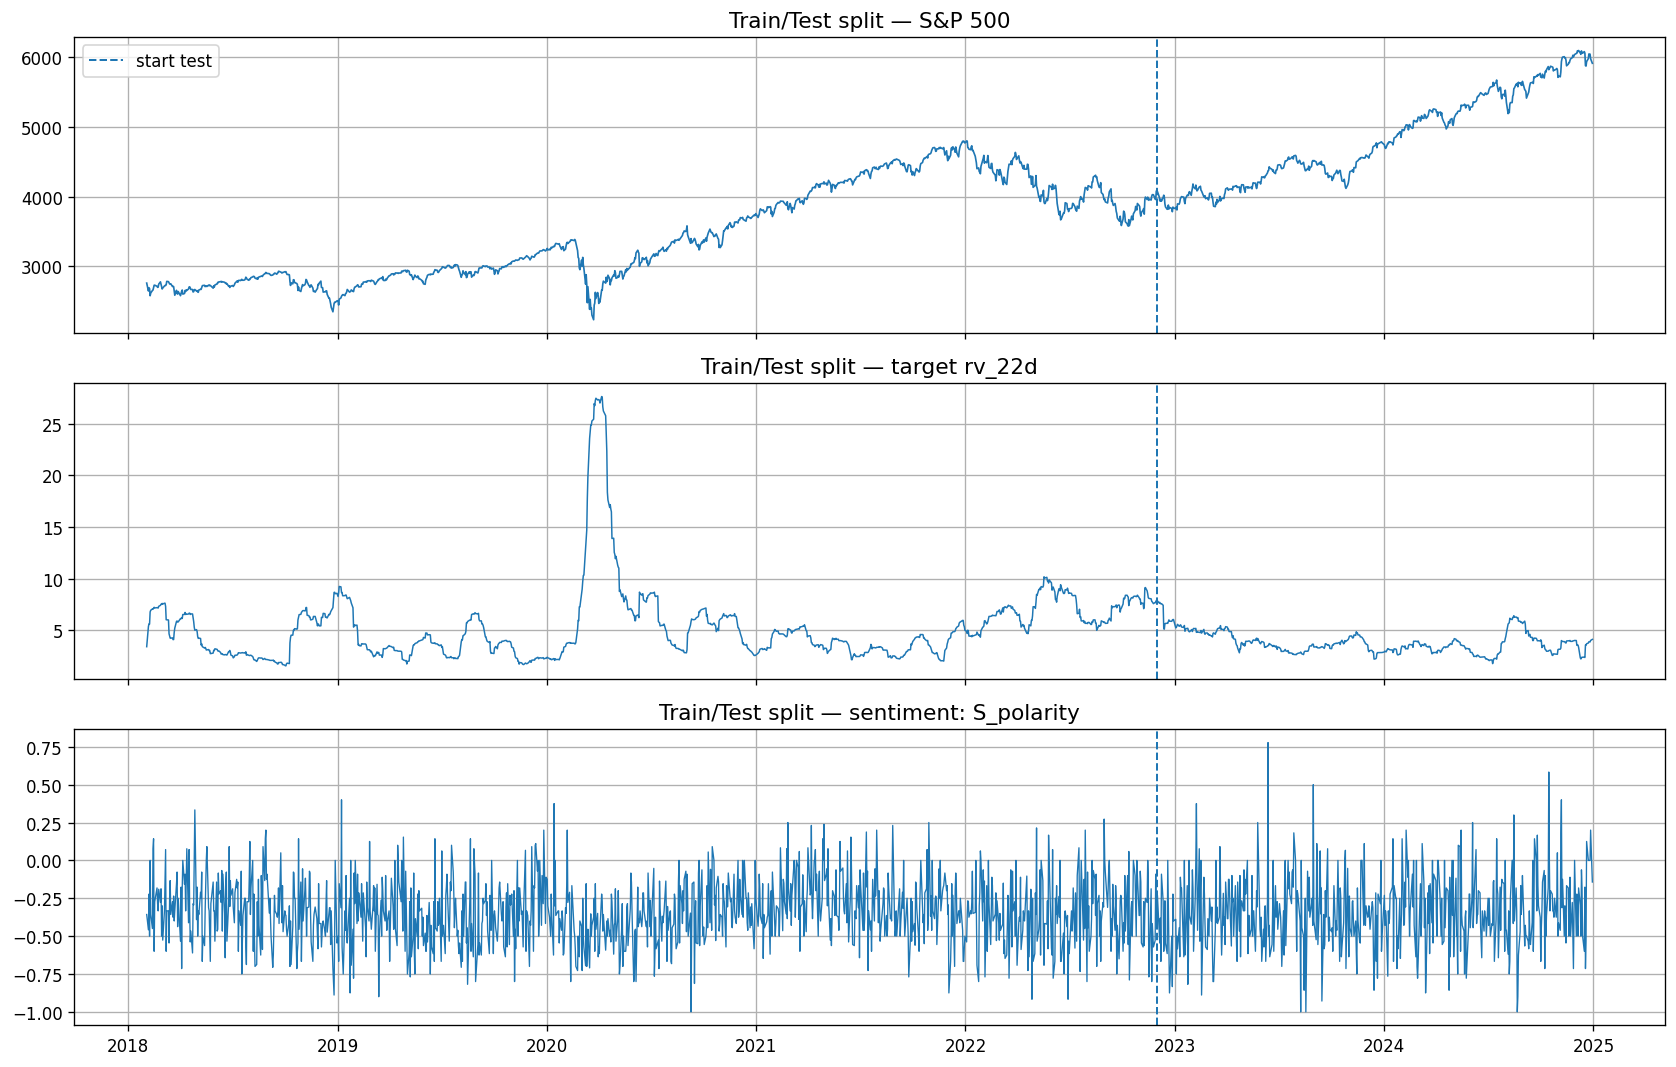

In [7]:
# ------------------------------------------------------------
# 4. TRAIN / TEST SPLIT
# ------------------------------------------------------------

# Dataset minim cu target și features disponibile
base_needed = [TARGET, 'r_t', 'r_t_sq', 'abs_r_t'] + preferred_sentiment_cols
if 'vix' in work.columns:
    base_needed.append('vix')

analysis_df = work.replace([np.inf, -np.inf], np.nan).dropna(subset=[TARGET]).copy()

split_idx = int(len(analysis_df) * SPLIT_RATIO)
split_date = analysis_df.index[split_idx]

train_df = analysis_df.iloc[:split_idx].copy()
test_df = analysis_df.iloc[split_idx:].copy()

print(f"Target: {TARGET}")
print(f"Train: {train_df.index.min().date()} → {train_df.index.max().date()} | n={len(train_df):,}")
print(f"Test:  {test_df.index.min().date()} → {test_df.index.max().date()} | n={len(test_df):,}")
print(f"Split date: {split_date.date()}")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(analysis_df.index, analysis_df[price_col], linewidth=1.0)
axes[0].axvline(split_date, linestyle='--', linewidth=1.2, label='start test')
axes[0].set_title('Train/Test split — S&P 500')
axes[0].legend()

axes[1].plot(analysis_df.index, analysis_df[TARGET], linewidth=0.9)
axes[1].axvline(split_date, linestyle='--', linewidth=1.2)
axes[1].set_title(f'Train/Test split — target {TARGET}')

if preferred_sentiment_cols:
    sent_plot_col = preferred_sentiment_cols[0]
    axes[2].plot(analysis_df.index, analysis_df[sent_plot_col], linewidth=0.8)
    axes[2].axvline(split_date, linestyle='--', linewidth=1.2)
    axes[2].set_title(f'Train/Test split — sentiment: {sent_plot_col}')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_train_test_split_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

### Funcții de evaluare și plotare

In [8]:
# ------------------------------------------------------------
# METRICS AND PLOTS
# ------------------------------------------------------------

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def safe_r2(y_true, y_pred):
    try:
        return float(r2_score(y_true, y_pred))
    except Exception:
        return np.nan


def qlike_var(y_true, y_pred, eps=1e-8):
    """QLIKE pe varianță. Pentru RV, folosim RV^2 ca varianță proxy."""
    y_true = np.maximum(np.asarray(y_true, dtype=float), eps)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), eps)
    return float(np.mean(np.log(y_pred) + y_true / y_pred))


def align_series(y_true, y_pred):
    y_true = pd.Series(y_true).dropna()
    y_pred = pd.Series(y_pred).dropna()
    idx = y_true.index.intersection(y_pred.index)
    return y_true.loc[idx], y_pred.loc[idx]


def evaluate_model(name, y_true, y_pred, family, uses_sentiment, target=TARGET):
    y, p = align_series(y_true, y_pred)
    p = p.clip(lower=0) if target.startswith('rv') else p
    return {
        'model': name,
        'family': family,
        'uses_sentiment': uses_sentiment,
        'target': target,
        'n_test': len(y),
        'MAE': mean_absolute_error(y, p),
        'RMSE': rmse(y, p),
        'MAPE': mape(y, p),
        'R2': safe_r2(y, p),
        'QLIKE_RV2': qlike_var(y**2, p.clip(lower=1e-8)**2) if target.startswith('rv') else np.nan,
    }


def plot_prediction(y_train, y_test, pred_dict, title, filename, window=PLOT_WINDOW):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_train.iloc[-120:].index, y_train.iloc[-120:], label='train final', linewidth=1.0)
    y_plot = y_test.iloc[:window]
    ax.plot(y_plot.index, y_plot, label='actual test', linewidth=1.4)

    for name, pred in pred_dict.items():
        pred = pd.Series(pred).dropna()
        pred_plot = pred.loc[y_plot.index.intersection(pred.index)]
        ax.plot(pred_plot.index, pred_plot, label=name, linewidth=1.2)

    ax.axvline(y_test.index[0], linestyle='--', linewidth=1.2, label='start test')
    ax.set_title(title)
    ax.set_ylabel(TARGET)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()


all_results = []
predictions = {}

## 5. Staționaritate și ordine de integrare

Testăm variabilele multivariate pentru a decide dacă folosim VAR sau VECM.

In [9]:
# ------------------------------------------------------------
# 5. STATIONARITY
# ------------------------------------------------------------

def stationarity_row(x, name):
    x = pd.Series(x).dropna()
    row = {'series': name, 'n': len(x)}
    try:
        adf = adfuller(x, autolag='AIC')
        row['ADF_pvalue'] = adf[1]
        row['ADF_decision'] = 'I(0) / stationary' if adf[1] < 0.05 else 'unit root likely'
    except Exception:
        row['ADF_pvalue'] = np.nan
        row['ADF_decision'] = 'error'
    try:
        kp = kpss(x, regression='c', nlags='auto')
        row['KPSS_pvalue'] = kp[1]
        row['KPSS_decision'] = 'stationary' if kp[1] > 0.05 else 'non-stationary likely'
    except Exception:
        row['KPSS_pvalue'] = np.nan
        row['KPSS_decision'] = 'error'
    if ARCH_OK:
        try:
            pp = PhillipsPerron(x)
            row['PP_pvalue'] = pp.pvalue
            row['PP_decision'] = 'I(0) / stationary' if pp.pvalue < 0.05 else 'unit root likely'
        except Exception:
            row['PP_pvalue'] = np.nan
            row['PP_decision'] = 'error'
    else:
        row['PP_pvalue'] = np.nan
        row['PP_decision'] = 'not available'
    return row

stationarity_vars = [price_col, 'log_price', 'r_t', 'r_t_sq', 'abs_r_t', TARGET]
if 'vix' in work.columns:
    stationarity_vars += ['vix', 'd_vix']
stationarity_vars += preferred_sentiment_cols
stationarity_vars = list(dict.fromkeys([v for v in stationarity_vars if v in analysis_df.columns]))

stationarity_df = pd.DataFrame([stationarity_row(train_df[v], v) for v in stationarity_vars]).set_index('series')
stationarity_df.to_csv(TABLE_DIR / '01_multivariate_stationarity_tests.csv')
stationarity_df.round(5)

,n,ADF_pvalue,ADF_decision,KPSS_pvalue,KPSS_decision,PP_pvalue,PP_decision
series,,,,,,,
adj_close,1216,0.67152,unit root likely,0.01000,non-stationary likely,0.70224,unit root likely
log_price,1216,0.62986,unit root likely,0.01000,non-stationary likely,0.67501,unit root likely
r_t,1216,0.00000,I(0) / stationary,0.10000,stationary,0.00000,I(0) / stationary
r_t_sq,1216,0.00000,I(0) / stationary,0.10000,stationary,0.00000,I(0) / stationary
abs_r_t,1216,0.00000,I(0) / stationary,0.10000,stationary,0.00000,I(0) / stationary
rv_22d,1216,0.05080,unit root likely,0.10000,stationary,0.00205,I(0) / stationary
vix,1216,0.00127,I(0) / stationary,0.01000,non-stationary likely,0.00007,I(0) / stationary
d_vix,1216,0.00000,I(0) / stationary,0.10000,stationary,0.00000,I(0) / stationary
S_polarity,1216,0.00000,I(0) / stationary,0.10000,stationary,0.00000,I(0) / stationary


## 6. Cointegrare și decizia VAR/VECM

VECM este adecvat doar dacă seriile sunt I(1) și co-integrate. Variabilele principale ale proiectului — randamentele, volatilitatea și sentimentul — sunt de obicei staționare. De aceea, cel mai probabil modelul principal va fi VAR pe variabile staționare, iar VECM va fi tratat metodologic / exploratoriu.

In [10]:
# ------------------------------------------------------------
# 6. JOHANSEN COINTEGRATION EXPLORATORY
# ------------------------------------------------------------

# Candidate I(1) variables: log_price and maybe log_vix.
johansen_candidates = ['log_price']
if 'log_vix' in analysis_df.columns:
    johansen_candidates.append('log_vix')

johansen_df = analysis_df[johansen_candidates].replace([np.inf, -np.inf], np.nan).dropna()

if len(johansen_candidates) >= 2 and len(johansen_df) > 100:
    try:
        joh = coint_johansen(johansen_df, det_order=0, k_ar_diff=1)
        johansen_res = pd.DataFrame({
            'rank_null': list(range(len(joh.lr1))),
            'trace_stat': joh.lr1,
            'crit_90': joh.cvt[:, 0],
            'crit_95': joh.cvt[:, 1],
            'crit_99': joh.cvt[:, 2],
            'reject_95': joh.lr1 > joh.cvt[:, 1]
        })
        johansen_res.to_csv(TABLE_DIR / '02_johansen_cointegration_exploratory.csv', index=False)
        display(johansen_res.round(4))
    except Exception as e:
        print('Johansen test failed:', e)
else:
    print('Nu avem suficiente variabile I(1) candidate pentru Johansen/VECM.')

print('\nDecizie metodologică: modelul principal va fi VAR pe variabile staționare / transformate.')

,rank_null,trace_stat,crit_90,crit_95,crit_99,reject_95
0,0,44.9394,13.4294,15.4943,19.9349,True
1,1,0.1563,2.7055,3.8415,6.6349,False



Decizie metodologică: modelul principal va fi VAR pe variabile staționare / transformate.


## 7. VAR: volatilitate, sentiment și factori financiari

Modelul VAR testează relațiile dinamice dintre volatilitate, randamente, VIX și sentiment. Lucrăm cu variabile staționare / standardizate.

In [11]:
# ------------------------------------------------------------
# 7. VAR DATASET
# ------------------------------------------------------------

# Alegem un set compact de variabile pentru VAR, ca să evităm supra-parametrizarea.
var_cols = [TARGET, 'r_t']

if 'vix' in analysis_df.columns:
    var_cols.append('vix')

# Adăugăm 2-3 variabile de sentiment interpretabile
for c in ['S_polarity', 'neg_share', 'S_mean', 'n_articles']:
    if c in analysis_df.columns and c not in var_cols:
        var_cols.append(c)
    if len(var_cols) >= 6:
        break

var_cols = [c for c in var_cols if c in analysis_df.columns]
var_df = analysis_df[var_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

split_idx_var = int(len(var_df) * SPLIT_RATIO)
var_train = var_df.iloc[:split_idx_var].copy()
var_test = var_df.iloc[split_idx_var:].copy()

# Standardizare pentru stabilitate numerică și IRF comparabile
var_scaler = StandardScaler()
var_train_s = pd.DataFrame(var_scaler.fit_transform(var_train), index=var_train.index, columns=var_cols)
var_test_s = pd.DataFrame(var_scaler.transform(var_test), index=var_test.index, columns=var_cols)

print('VAR columns:', var_cols)
print(f'VAR train: {var_train.index.min().date()} → {var_train.index.max().date()} | n={len(var_train)}')
print(f'VAR test:  {var_test.index.min().date()} → {var_test.index.max().date()} | n={len(var_test)}')
var_train.describe().T.round(4)

VAR columns: ['rv_22d', 'r_t', 'vix', 'S_polarity', 'neg_share', 'S_mean']
VAR train: 2018-02-02 → 2022-11-30 | n=1216
VAR test:  2022-12-01 → 2024-12-30 | n=522


,count,mean,std,min,25%,50%,75%,max
rv_22d,1216.0,5.3574,3.7167,1.5587,3.0571,4.5751,6.5549,27.6406
r_t,1216.0,0.0303,1.3972,-12.7652,-0.5322,0.0882,0.7131,8.9683
vix,1216.0,21.4940,8.4863,10.8500,15.7750,19.8000,25.5600,82.6900
S_polarity,1216.0,-0.3373,0.2162,-1.0000,-0.5000,-0.3478,-0.1875,0.4000
neg_share,1216.0,0.4714,0.1507,0.0000,0.3636,0.4667,0.5714,1.0000
S_mean,1216.0,-0.2938,0.1798,-0.8429,-0.4142,-0.3001,-0.1729,0.3748


In [12]:
# ------------------------------------------------------------
# 7.1 VAR LAG SELECTION AND FIT
# ------------------------------------------------------------

maxlags = min(MAX_VAR_LAGS, max(1, len(var_train_s)//10))
var_model = VAR(var_train_s)
lag_selection = var_model.select_order(maxlags=maxlags)
print(lag_selection.summary())

selected_lag = lag_selection.selected_orders.get('bic')
if selected_lag is None or selected_lag == 0 or np.isnan(selected_lag):
    selected_lag = lag_selection.selected_orders.get('aic')
if selected_lag is None or selected_lag == 0 or np.isnan(selected_lag):
    selected_lag = 1
selected_lag = int(selected_lag)

print('Selected VAR lag:', selected_lag)
var_fit = var_model.fit(selected_lag)
print(var_fit.summary())
print('VAR stable:', var_fit.is_stable(verbose=False))

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -6.433      -6.407    0.001608      -6.423
1       -13.71     -13.53*   1.112e-06      -13.64
2       -13.79      -13.46   1.027e-06     -13.66*
3       -13.80      -13.32   1.017e-06      -13.62
4       -13.78      -13.15   1.036e-06      -13.54
5       -13.85      -13.06   9.656e-07      -13.55
6       -13.87      -12.93   9.464e-07      -13.52
7       -13.90      -12.81   9.228e-07      -13.49
8       -13.87      -12.63   9.458e-07      -13.40
9      -13.90*      -12.51  9.191e-07*      -13.38
10      -13.88      -12.33   9.408e-07      -13.29
--------------------------------------------------
Selected VAR lag: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 13, Jun, 2026
Time:                     16:05:58
----------------------------------------

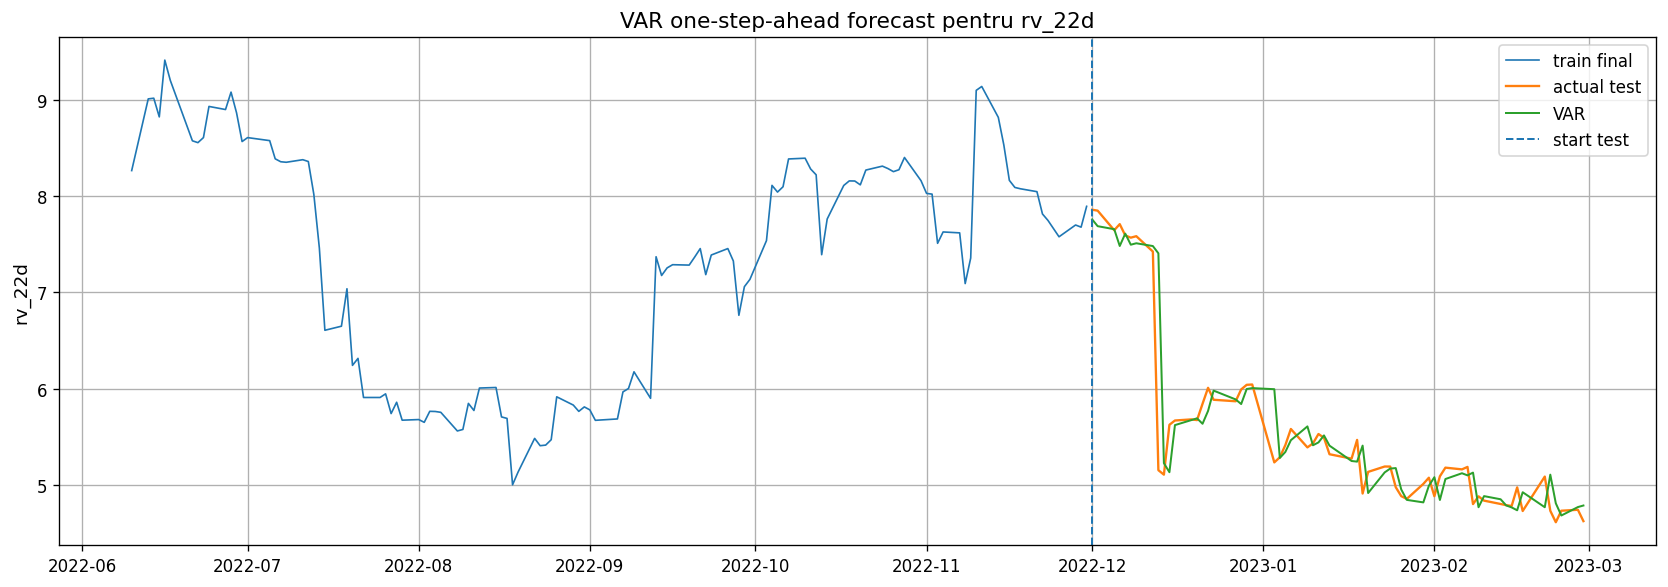

In [13]:
# ------------------------------------------------------------
# 7.2 VAR ONE-STEP-AHEAD FORECAST ON TEST
# ------------------------------------------------------------

def var_one_step_forecast(var_fit, train_s, test_s, scaler, columns, target_col):
    history = train_s.copy()
    preds_scaled = []
    for t in test_s.index:
        yhat = var_fit.forecast(history.values[-var_fit.k_ar:], steps=1)[0]
        preds_scaled.append(yhat)
        # one-step-ahead evaluation: după prognoză observăm valoarea reală și actualizăm istoricul
        history = pd.concat([history, test_s.loc[[t]]])
    pred_s = pd.DataFrame(preds_scaled, index=test_s.index, columns=columns)
    pred_unscaled = pd.DataFrame(scaler.inverse_transform(pred_s), index=test_s.index, columns=columns)
    return pred_unscaled[target_col]

var_pred = var_one_step_forecast(var_fit, var_train_s, var_test_s, var_scaler, var_cols, TARGET)
var_pred = var_pred.clip(lower=0)
predictions['VAR'] = var_pred
all_results.append(evaluate_model('VAR multivariate', var_test[TARGET], var_pred, 'VAR', uses_sentiment=True))

plot_prediction(
    var_train[TARGET], var_test[TARGET], {'VAR': var_pred},
    title=f'VAR one-step-ahead forecast pentru {TARGET}',
    filename='02_var_forecast_rv22d.png'
)

### 7.3. Cauzalitatea Granger

Testăm dacă sentimentul ajută la prognoza volatilității peste trecutul propriu al volatilității.

In [14]:
# ------------------------------------------------------------
# 7.3 GRANGER CAUSALITY TESTS IN VAR
# ------------------------------------------------------------

granger_rows = []
caused_targets = [TARGET]
if 'r_t' in var_cols:
    caused_targets.append('r_t')

causing_candidates = [c for c in preferred_sentiment_cols + ['vix'] if c in var_cols]

for caused in caused_targets:
    for causing in causing_candidates:
        if caused == causing:
            continue
        try:
            test_res = var_fit.test_causality(caused=caused, causing=[causing], kind='f')
            granger_rows.append({
                'caused': caused,
                'causing': causing,
                'test_statistic': test_res.test_statistic,
                'pvalue': test_res.pvalue,
                'decision_5pct': 'Granger-causal' if test_res.pvalue < 0.05 else 'not significant'
            })
        except Exception as e:
            granger_rows.append({
                'caused': caused,
                'causing': causing,
                'test_statistic': np.nan,
                'pvalue': np.nan,
                'decision_5pct': f'error: {e}'
            })

granger_df = pd.DataFrame(granger_rows).sort_values(['caused', 'pvalue'])
granger_df.to_csv(TABLE_DIR / '03_var_granger_causality.csv', index=False)
granger_df.round(6)

,caused,causing,test_statistic,pvalue,decision_5pct
4,r_t,S_polarity,1.646673,0.199453,not significant
5,r_t,S_mean,1.476910,0.224298,not significant
7,r_t,vix,1.408532,0.235339,not significant
6,r_t,neg_share,0.030260,0.861906,not significant
3,rv_22d,vix,130.344519,0.000000,Granger-causal
2,rv_22d,neg_share,1.007160,0.315618,not significant
0,rv_22d,S_polarity,0.010510,0.918350,not significant
1,rv_22d,S_mean,0.003770,0.951044,not significant


### 7.4. IRF și FEVD

IRF arată cum reacționează volatilitatea la un șoc în sentiment. FEVD arată cât din eroarea de prognoză a volatilității este explicată de șocuri în celelalte variabile.

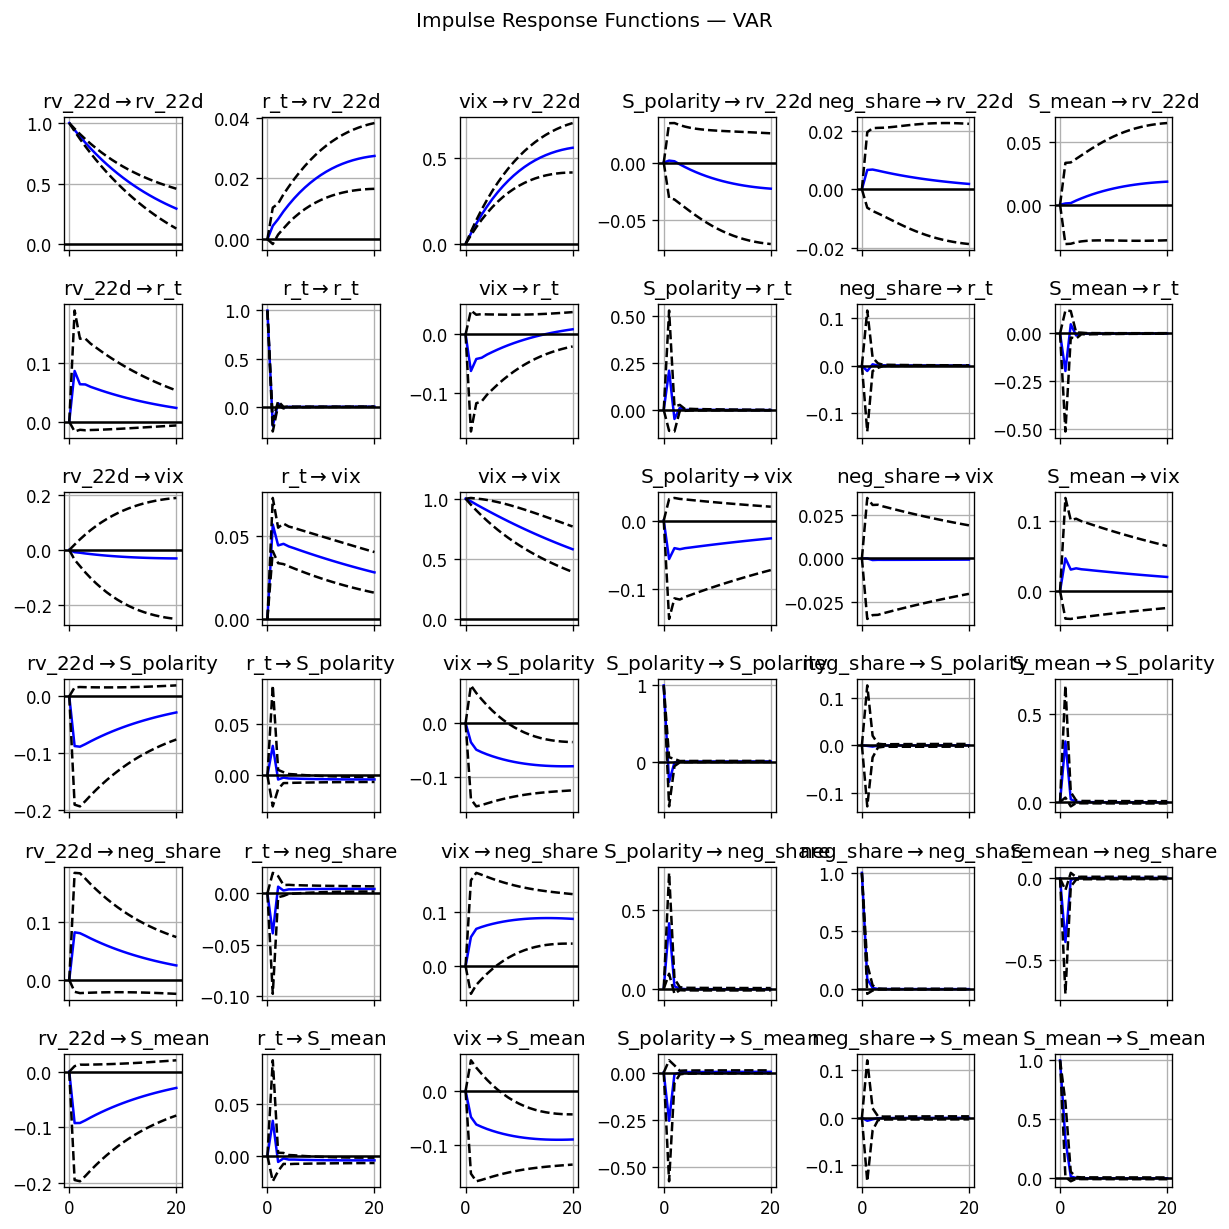

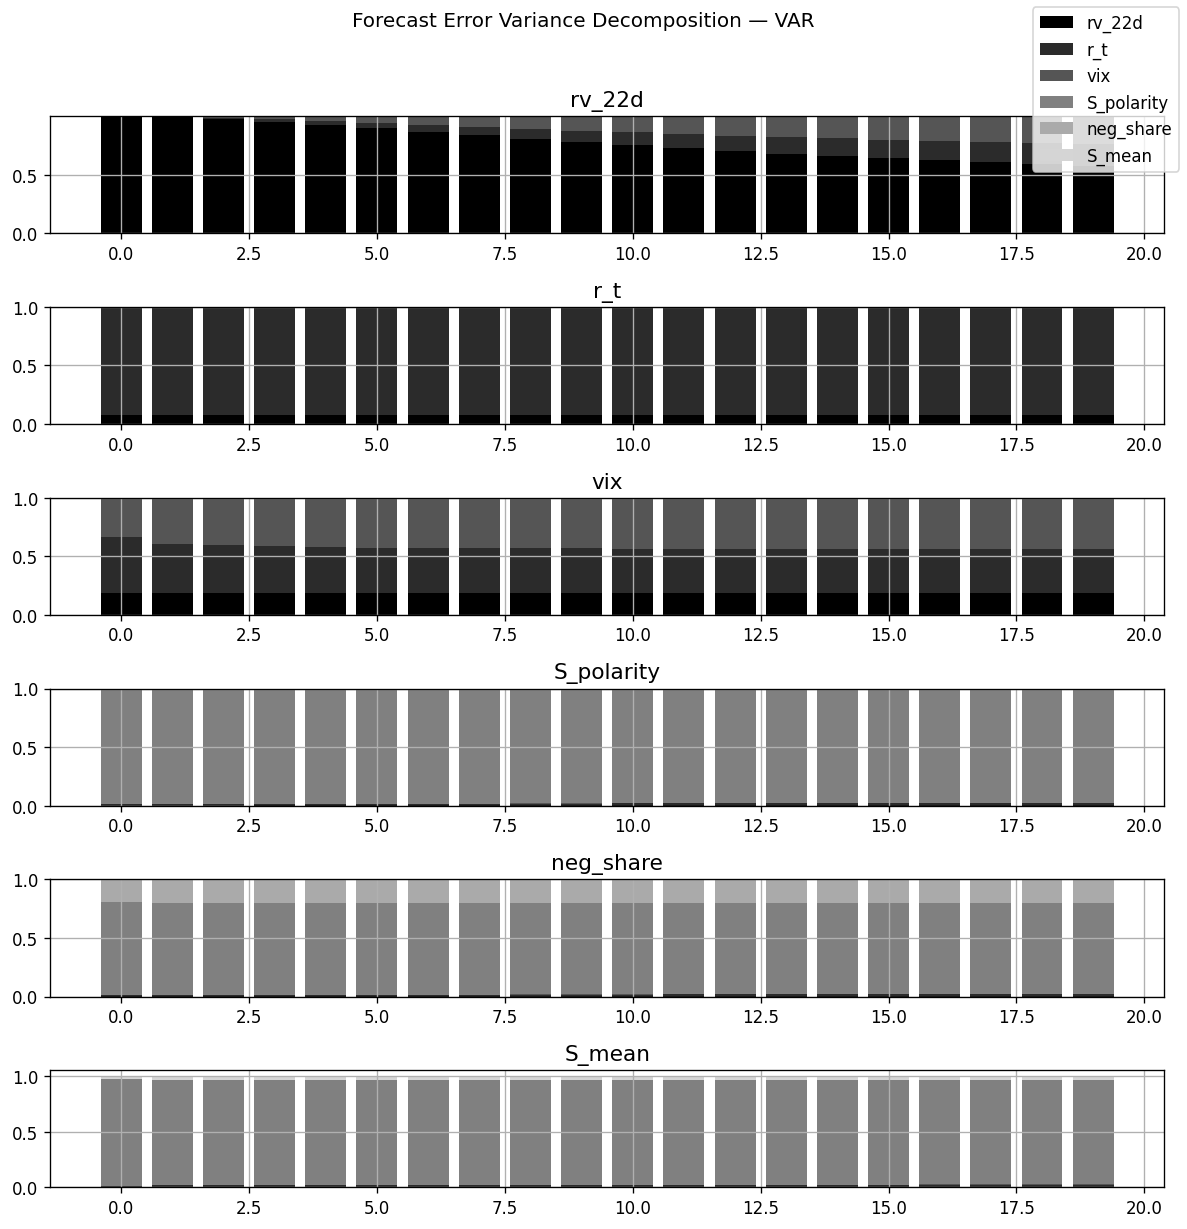

In [15]:
# ------------------------------------------------------------
# 7.4 IRF AND FEVD
# ------------------------------------------------------------

try:
    irf = var_fit.irf(20)
    fig = irf.plot(orth=False)
    fig.suptitle('Impulse Response Functions — VAR', y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '03_var_irf.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print('IRF plot failed:', e)

try:
    fevd = var_fit.fevd(20)
    fig = fevd.plot()
    fig.suptitle('Forecast Error Variance Decomposition — VAR', y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / '04_var_fevd.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print('FEVD plot failed:', e)

## 8. Efecte ARCH/GARCH în context multivariat

Aici verificăm dacă reziduurile VAR mai conțin efecte ARCH/GARCH. Dacă da, înseamnă că relațiile multivariate de medie nu sunt suficiente și volatilitatea condițională trebuie modelată separat.

Aceasta este echivalentul multivariat al logicii din Notebook 02: după ce modelăm sistemul, verificăm dacă reziduurile au volatilitate condițională.

In [16]:
# ------------------------------------------------------------
# 8. ARCH TESTS ON VAR RESIDUALS
# ------------------------------------------------------------

var_resid = var_fit.resid.copy()
arch_rows = []

for col in var_resid.columns:
    resid = var_resid[col].dropna()
    try:
        arch = het_arch(resid, nlags=10)
        lb_resid = acorr_ljungbox(resid, lags=[10], return_df=True)
        lb_sq = acorr_ljungbox(resid**2, lags=[10], return_df=True)
        arch_rows.append({
            'residual_series': col,
            'ARCH_LM_pvalue': arch[1],
            'LB_resid_pvalue_lag10': lb_resid['lb_pvalue'].iloc[0],
            'LB_sq_resid_pvalue_lag10': lb_sq['lb_pvalue'].iloc[0],
            'ARCH_decision_5pct': 'ARCH effects' if arch[1] < 0.05 else 'no ARCH effects'
        })
    except Exception as e:
        arch_rows.append({'residual_series': col, 'error': str(e)})

var_arch_df = pd.DataFrame(arch_rows)
var_arch_df.to_csv(TABLE_DIR / '04_arch_tests_on_var_residuals.csv', index=False)
var_arch_df.round(6)

,residual_series,ARCH_LM_pvalue,LB_resid_pvalue_lag10,LB_sq_resid_pvalue_lag10,ARCH_decision_5pct
0,rv_22d,0.000000,0.000000,0.000000,ARCH effects
1,r_t,0.000000,0.000000,0.000000,ARCH effects
2,vix,0.000000,0.000005,0.000000,ARCH effects
3,S_polarity,0.464976,0.129521,0.417279,no ARCH effects
4,neg_share,0.561053,0.010618,0.575251,no ARCH effects
5,S_mean,0.651455,0.044444,0.628690,no ARCH effects


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                       rv_22d   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                            GARCH   Log-Likelihood:                1583.81
Distribution:      Standardized Student's t   AIC:                          -3159.62
Method:                  Maximum Likelihood   BIC:                          -3139.21
                                              No. Observations:                 1215
Date:                      Sat, Jun 13 2026   Df Residuals:                     1215
Time:                              16:06:01   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

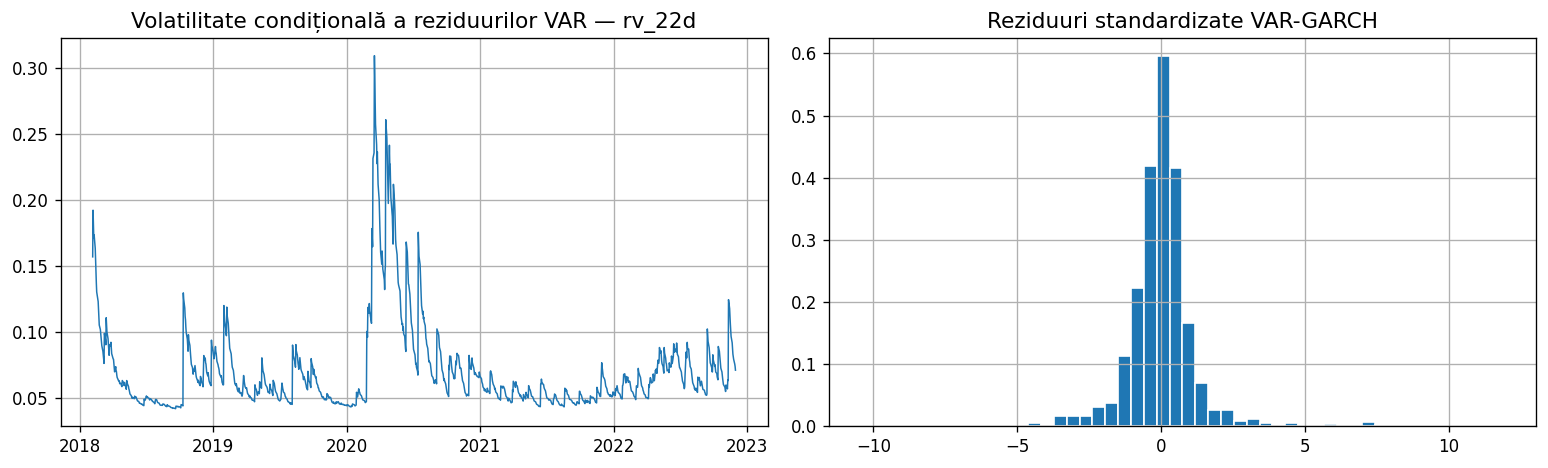

In [17]:
# ------------------------------------------------------------
# 8.1 GARCH ON VAR TARGET RESIDUALS
# ------------------------------------------------------------
# Estimăm GARCH pe reziduurile ecuației target din VAR, ca verificare a volatilității reziduale.

if ARCH_OK and TARGET in var_resid.columns:
    try:
        target_resid = var_resid[TARGET].dropna()
        var_resid_garch = arch_model(target_resid, mean='Zero', vol='GARCH', p=1, q=1, dist='t', rescale=False).fit(disp='off')
        print(var_resid_garch.summary())

        std_resid = var_resid_garch.std_resid.dropna()
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].plot(var_resid_garch.conditional_volatility, linewidth=0.9)
        axes[0].set_title(f'Volatilitate condițională a reziduurilor VAR — {TARGET}')
        axes[1].hist(std_resid, bins=50, density=True, edgecolor='white')
        axes[1].set_title('Reziduuri standardizate VAR-GARCH')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '05_var_residual_garch.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print('GARCH on VAR residuals failed:', e)
else:
    print('ARCH unavailable sau targetul nu este în reziduurile VAR.')

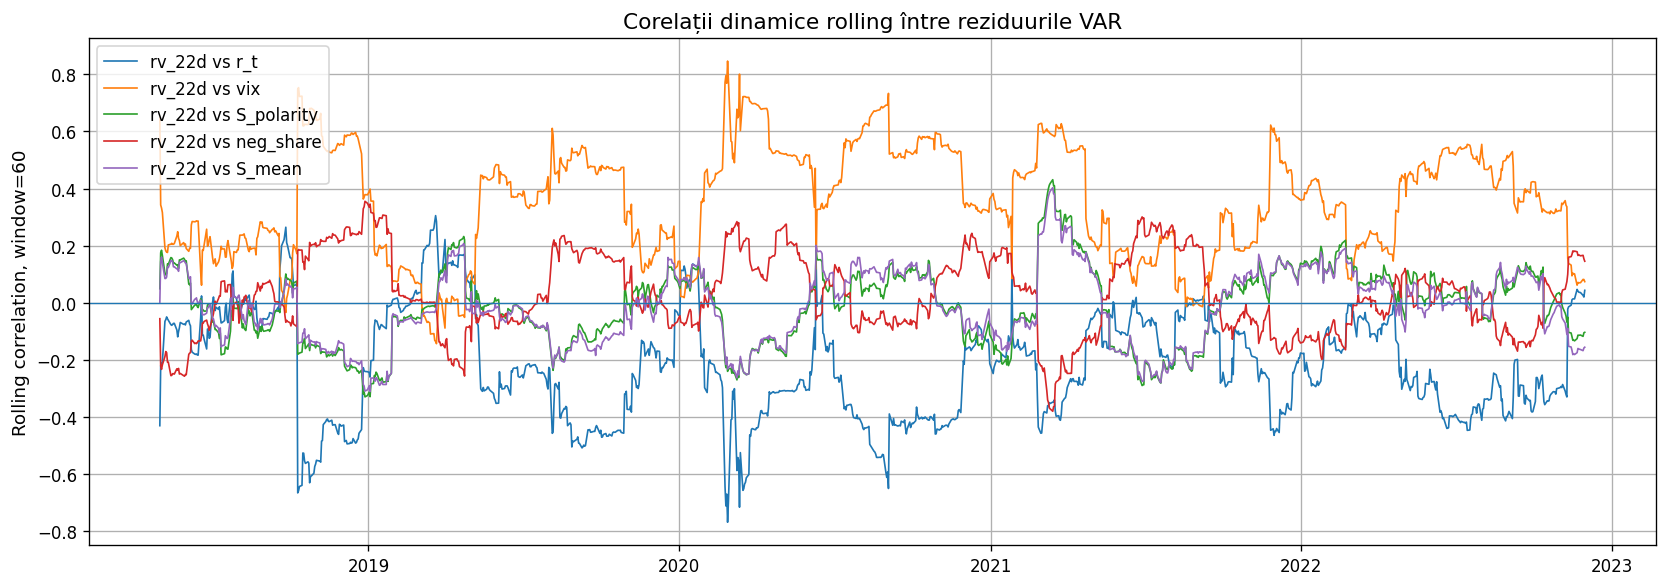

In [18]:
# ------------------------------------------------------------
# 8.2 DCC-like / rolling correlation of VAR residuals
# ------------------------------------------------------------
# Nu este DCC-GARCH complet, dar oferă o aproximare vizuală a corelațiilor dinamice între șocuri.

if TARGET in var_resid.columns and len(var_resid.columns) >= 2:
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in var_resid.columns:
        if col == TARGET:
            continue
        corr = var_resid[TARGET].rolling(60).corr(var_resid[col])
        ax.plot(corr.index, corr, linewidth=1.0, label=f'{TARGET} vs {col}')
    ax.axhline(0, linewidth=0.8)
    ax.set_title('Corelații dinamice rolling între reziduurile VAR')
    ax.set_ylabel('Rolling correlation, window=60')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06_var_residual_rolling_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. HAR-RV și HAR-RV-X

HAR-RV este un model foarte potrivit pentru volatilitate realizată. Folosește componente de volatilitate pe orizonturi diferite:

$$RV_t = \beta_0 + \beta_1 RV_{t-1} + \beta_2 RV_{t-5:t-1} + \beta_3 RV_{t-22:t-1} + \varepsilon_t$$

Varianta HAR-RV-X adaugă sentimentul financiar lagged:

$$RV_t = HAR\ terms + \gamma Sentiment_{t-1} + \varepsilon_t$$

In [19]:
# ------------------------------------------------------------
# 9. HAR-RV DATASET
# ------------------------------------------------------------

har_base_cols = ['rv_lag1', 'rv_week', 'rv_month']
har_sent_cols = []
for c in preferred_sentiment_cols:
    lag_col = f'{c}_lag1'
    if lag_col in work.columns:
        har_sent_cols.append(lag_col)

har_cols_no_sent = har_base_cols
har_cols_with_sent = har_base_cols + har_sent_cols

har_df = work[[TARGET] + har_cols_with_sent].replace([np.inf, -np.inf], np.nan).dropna().copy()

split_idx_har = int(len(har_df) * SPLIT_RATIO)
har_train = har_df.iloc[:split_idx_har]
har_test = har_df.iloc[split_idx_har:]

print('HAR base cols:', har_cols_no_sent)
print('HAR sentiment cols:', har_sent_cols)
print(f'HAR train: {har_train.index.min().date()} → {har_train.index.max().date()} | n={len(har_train)}')
print(f'HAR test:  {har_test.index.min().date()} → {har_test.index.max().date()} | n={len(har_test)}')

HAR base cols: ['rv_lag1', 'rv_week', 'rv_month']
HAR sentiment cols: ['S_polarity_lag1', 'S_mean_lag1', 'S_sum_lag1', 'neg_share_lag1', 'pos_share_lag1', 'n_articles_lag1']
HAR train: 2018-03-07 → 2022-12-09 | n=1201
HAR test:  2022-12-12 → 2024-12-30 | n=515


=== HAR-RV ===
                            OLS Regression Results                            
Dep. Variable:                 rv_22d   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     8622.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:06:02   Log-Likelihood:                -459.05
No. Observations:                1201   AIC:                             926.1
Df Residuals:                    1197   BIC:                             946.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0943      0.030     

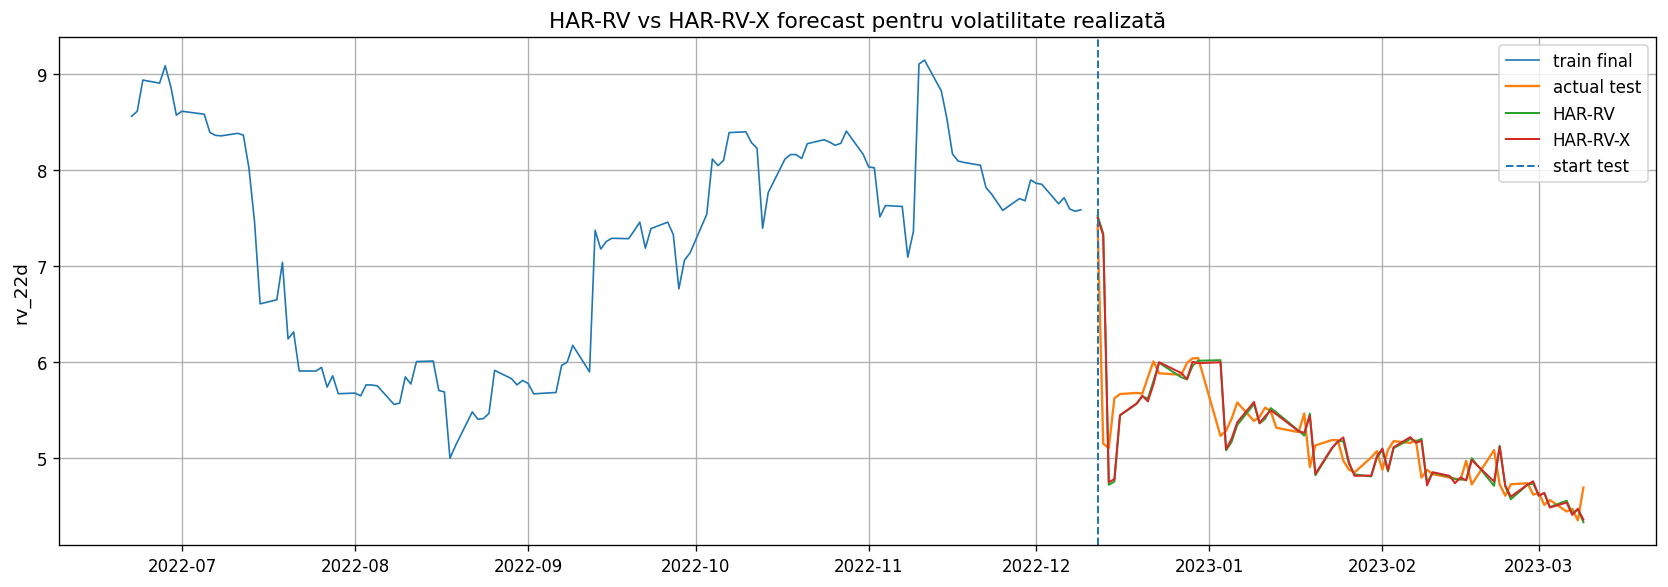

In [20]:
# ------------------------------------------------------------
# 9.1 FIT HAR-RV AND HAR-RV-X
# ------------------------------------------------------------

def fit_ols_predict(train_data, test_data, y_col, x_cols, model_name):
    X_train = sm.add_constant(train_data[x_cols], has_constant='add')
    y_train = train_data[y_col]
    X_test = sm.add_constant(test_data[x_cols], has_constant='add')
    model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    pred = pd.Series(model.predict(X_test), index=test_data.index, name=model_name).clip(lower=0)
    return model, pred

har_model, har_pred = fit_ols_predict(har_train, har_test, TARGET, har_cols_no_sent, 'HAR-RV')
harx_model, harx_pred = fit_ols_predict(har_train, har_test, TARGET, har_cols_with_sent, 'HAR-RV-X')

predictions['HAR-RV'] = har_pred
predictions['HAR-RV-X'] = harx_pred
all_results.append(evaluate_model('HAR-RV', har_test[TARGET], har_pred, 'HAR-RV', uses_sentiment=False))
all_results.append(evaluate_model('HAR-RV-X', har_test[TARGET], harx_pred, 'HAR-RV-X', uses_sentiment=True))

print('=== HAR-RV ===')
print(har_model.summary())
print('\n=== HAR-RV-X ===')
print(harx_model.summary())

plot_prediction(
    har_train[TARGET], har_test[TARGET],
    {'HAR-RV': har_pred, 'HAR-RV-X': harx_pred},
    title='HAR-RV vs HAR-RV-X forecast pentru volatilitate realizată',
    filename='07_har_rv_vs_harx_forecast.png'
)

## 10. Machine Learning: MLP fără sentiment vs. MLP cu sentiment

Construim două seturi de features:

- **fără sentiment:** laguri financiare;
- **cu sentiment:** laguri financiare + laguri de sentiment.

In [21]:
# ------------------------------------------------------------
# 10. TABULAR ML DATASET
# ------------------------------------------------------------

financial_lag_cols = []
for c in financial_cols:
    for lag in ML_LAGS:
        lc = f'{c}_lag{lag}'
        if lc in work.columns:
            financial_lag_cols.append(lc)

sentiment_lag_cols = []
for c in preferred_sentiment_cols:
    for lag in ML_LAGS:
        lc = f'{c}_lag{lag}'
        if lc in work.columns:
            sentiment_lag_cols.append(lc)

ml_cols_no_sent = financial_lag_cols
ml_cols_with_sent = financial_lag_cols + sentiment_lag_cols

ml_df = work[[TARGET] + ml_cols_with_sent].replace([np.inf, -np.inf], np.nan).dropna().copy()

split_idx_ml = int(len(ml_df) * SPLIT_RATIO)
ml_train = ml_df.iloc[:split_idx_ml]
ml_test = ml_df.iloc[split_idx_ml:]

print('Nr. financial lag cols:', len(financial_lag_cols))
print('Nr. sentiment lag cols:', len(sentiment_lag_cols))
print(f'ML train: {ml_train.index.min().date()} → {ml_train.index.max().date()} | n={len(ml_train)}')
print(f'ML test:  {ml_test.index.min().date()} → {ml_test.index.max().date()} | n={len(ml_test)}')

Nr. financial lag cols: 42
Nr. sentiment lag cols: 36
ML train: 2018-03-07 → 2022-12-09 | n=1201
ML test:  2022-12-12 → 2024-12-30 | n=515


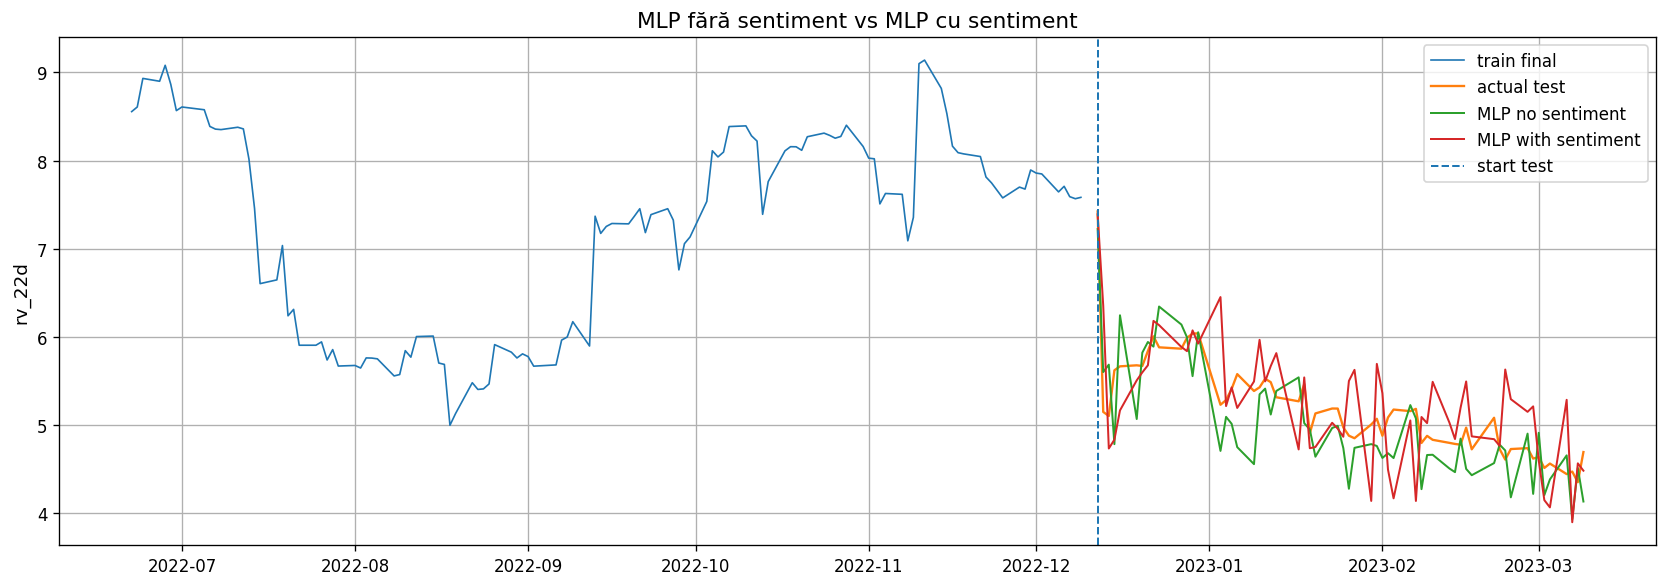

In [22]:
# ------------------------------------------------------------
# 10.1 MLP MODELS
# ------------------------------------------------------------

def fit_mlp(train_data, test_data, feature_cols, y_col=TARGET, hidden=(64, 32), random_state=42):
    X_train = train_data[feature_cols]
    y_train = train_data[y_col]
    X_test = test_data[feature_cols]

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=3000,
            random_state=random_state,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=60
        ))
    ])
    model.fit(X_train, y_train)
    pred = pd.Series(model.predict(X_test), index=test_data.index).clip(lower=0)
    return model, pred

mlp_no_sent_model, mlp_no_sent_pred = fit_mlp(ml_train, ml_test, ml_cols_no_sent, hidden=(64, 32))
mlp_sent_model, mlp_sent_pred = fit_mlp(ml_train, ml_test, ml_cols_with_sent, hidden=(64, 32))

predictions['MLP no sentiment'] = mlp_no_sent_pred
predictions['MLP with sentiment'] = mlp_sent_pred

all_results.append(evaluate_model('MLP no sentiment', ml_test[TARGET], mlp_no_sent_pred, 'MLP', uses_sentiment=False))
all_results.append(evaluate_model('MLP with sentiment', ml_test[TARGET], mlp_sent_pred, 'MLP', uses_sentiment=True))

plot_prediction(
    ml_train[TARGET], ml_test[TARGET],
    {'MLP no sentiment': mlp_no_sent_pred, 'MLP with sentiment': mlp_sent_pred},
    title='MLP fără sentiment vs MLP cu sentiment',
    filename='08_mlp_no_sent_vs_sent.png'
)


## 11. RNN și LSTM

Modelele RNN/LSTM folosesc secvențe de observații. Construim două variante:

- fără sentiment;
- cu sentiment.

Targetul este $RV_{22,t}$, iar inputul este secvența ultimelor `SEQ_LEN` zile.

In [23]:
# ------------------------------------------------------------
# 11. SEQUENCE DATASET FOR RNN/LSTM
# ------------------------------------------------------------


def create_sequences(df_in, feature_cols, target_col, seq_len=10):
    """
    Creează secvențe pentru RNN/LSTM fără leakage.

    X_i = valorile feature-urilor din ultimele `seq_len` zile
    y_i = targetul din ziua curentă, întotdeauna vector 1D

    IMPORTANT:
    - target_col este scos din feature_cols dacă apare acolo;
    - coloanele duplicate sunt eliminate;
    - y este forțat explicit ca array 1D.
    """
    feature_cols = list(dict.fromkeys(feature_cols))
    feature_cols = [c for c in feature_cols if c != target_col]

    needed_cols = feature_cols + [target_col]
    data = df_in.loc[:, needed_cols].copy()
    data = data.loc[:, ~data.columns.duplicated()].copy()
    data = data.replace([np.inf, -np.inf], np.nan).dropna().copy()

    if target_col not in data.columns:
        raise ValueError(f"Target column {target_col!r} not found after preprocessing.")
    if len(feature_cols) == 0:
        raise ValueError('No feature columns available for sequence model.')
    if len(data) <= seq_len:
        raise ValueError(f'Not enough observations for seq_len={seq_len}. Available rows: {len(data)}')

    values_X = data[feature_cols].to_numpy(dtype=float)
    values_y = data[target_col].to_numpy(dtype=float).reshape(-1)
    dates = data.index

    X, y, idx = [], [], []
    for i in range(seq_len, len(data)):
        X.append(values_X[i-seq_len:i, :])
        y.append(values_y[i])
        idx.append(dates[i])

    return np.asarray(X, dtype=float), np.asarray(y, dtype=float).reshape(-1), pd.Index(idx)


# Features secvențiale: valori istorice, nu coloane lagged.
# Scoatem TARGET din input ca să nu apară duplicat și ca să nu modelăm targetul contemporan.
seq_financial_cols = [c for c in ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'rv_22d', 'vix'] if c in work.columns and c != TARGET]
seq_sentiment_cols = [c for c in preferred_sentiment_cols if c in work.columns]
seq_cols_no_sent = list(dict.fromkeys(seq_financial_cols))
seq_cols_with_sent = list(dict.fromkeys(seq_financial_cols + seq_sentiment_cols))

seq_base_cols = list(dict.fromkeys([TARGET] + seq_cols_with_sent))
seq_df = work.loc[:, seq_base_cols].copy()
seq_df = seq_df.loc[:, ~seq_df.columns.duplicated()].copy()
seq_df = seq_df.replace([np.inf, -np.inf], np.nan).dropna().copy()

X_no_sent, y_seq, idx_seq = create_sequences(seq_df, seq_cols_no_sent, TARGET, seq_len=SEQ_LEN)
X_with_sent, y_seq2, idx_seq2 = create_sequences(seq_df, seq_cols_with_sent, TARGET, seq_len=SEQ_LEN)

# Aliniere pe date comune între modelul fără sentiment și cel cu sentiment
common_idx = idx_seq.intersection(idx_seq2)
mask_no = idx_seq.isin(common_idx)
mask_with = idx_seq2.isin(common_idx)

X_no_sent = X_no_sent[mask_no]
X_with_sent = X_with_sent[mask_with]
y_seq = y_seq[mask_no].reshape(-1)
y_seq2 = y_seq2[mask_with].reshape(-1)
idx_seq = idx_seq[mask_no]
idx_seq2 = idx_seq2[mask_with]

# Verificare defensivă: targetul trebuie să fie identic pe cele două seturi de secvențe
if len(y_seq) != len(y_seq2) or not np.allclose(y_seq, y_seq2, equal_nan=True):
    raise ValueError('Targets are not aligned between no-sentiment and with-sentiment sequence datasets.')

split_idx_seq = int(len(idx_seq) * SPLIT_RATIO)

X_no_train, X_no_test = X_no_sent[:split_idx_seq], X_no_sent[split_idx_seq:]
X_sent_train, X_sent_test = X_with_sent[:split_idx_seq], X_with_sent[split_idx_seq:]
y_train_seq, y_test_seq = y_seq[:split_idx_seq].reshape(-1), y_seq[split_idx_seq:].reshape(-1)
idx_train_seq, idx_test_seq = idx_seq[:split_idx_seq], idx_seq[split_idx_seq:]

# Serii target reutilizabile în celulele RNN/LSTM/DM
y_train_seq_series = pd.Series(y_train_seq, index=idx_train_seq, name=TARGET)
y_test_seq_series = pd.Series(y_test_seq, index=idx_test_seq, name=TARGET)

print('Sequence length:', SEQ_LEN)
print('No sentiment features:', seq_cols_no_sent)
print('With sentiment features:', seq_cols_with_sent)
print('No sentiment input shape:', X_no_train.shape, X_no_test.shape)
print('With sentiment input shape:', X_sent_train.shape, X_sent_test.shape)
print('y_train_seq shape:', y_train_seq.shape, '| y_test_seq shape:', y_test_seq.shape)
print(f'Seq train: {idx_train_seq.min().date()} → {idx_train_seq.max().date()} | n={len(idx_train_seq)}')
print(f'Seq test:  {idx_test_seq.min().date()} → {idx_test_seq.max().date()} | n={len(idx_test_seq)}')


Sequence length: 10
No sentiment features: ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'vix']
With sentiment features: ['r_t', 'r_t_sq', 'abs_r_t', 'rv_5d', 'vix', 'S_polarity', 'S_mean', 'S_sum', 'neg_share', 'pos_share', 'n_articles']
No sentiment input shape: (1209, 10, 5) (519, 10, 5)
With sentiment input shape: (1209, 10, 11) (519, 10, 11)
y_train_seq shape: (1209,) | y_test_seq shape: (519,)
Seq train: 2018-02-16 → 2022-12-05 | n=1209
Seq test:  2022-12-06 → 2024-12-30 | n=519


In [24]:
# ------------------------------------------------------------
# 11.1 SCALE 3D SEQUENCES
# ------------------------------------------------------------

def scale_3d_train_test(X_train, X_test):
    n_train, seq_len, n_features = X_train.shape
    n_test = X_test.shape[0]
    scaler = StandardScaler()
    X_train_2d = X_train.reshape(-1, n_features)
    X_test_2d = X_test.reshape(-1, n_features)
    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_features)
    X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, seq_len, n_features)
    return X_train_scaled, X_test_scaled, scaler

X_no_train_s, X_no_test_s, scaler_no_seq = scale_3d_train_test(X_no_train, X_no_test)
X_sent_train_s, X_sent_test_s, scaler_sent_seq = scale_3d_train_test(X_sent_train, X_sent_test)

# Scale target pentru neural nets, apoi inversăm predicțiile
yscaler = StandardScaler()
y_train_seq_s = yscaler.fit_transform(y_train_seq.reshape(-1, 1)).ravel()
y_test_seq_s = yscaler.transform(y_test_seq.reshape(-1, 1)).ravel()

print('Scaled sequence data ready.')

Scaled sequence data ready.


In [25]:
# ------------------------------------------------------------
# 11.2 RNN / LSTM FUNCTIONS
# ------------------------------------------------------------

if TF_OK:
    def build_rnn(input_shape, model_type='RNN'):
        model = Sequential()
        model.add(Input(shape=input_shape))
        if model_type == 'RNN':
            model.add(SimpleRNN(64, activation='tanh'))
        elif model_type == 'LSTM':
            model.add(LSTM(64, activation='tanh'))
        else:
            raise ValueError('model_type must be RNN or LSTM')
        model.add(Dropout(0.20))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(0.10))
        model.add(Dense(1))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), loss='mse', metrics=['mae'])
        return model

    def fit_deep_model(X_train, y_train, X_test, model_type='RNN'):
        model = build_rnn(input_shape=X_train.shape[1:], model_type=model_type)
        es = EarlyStopping(
            monitor='val_loss',
            patience=DL_PATIENCE,
            restore_best_weights=True,
            min_delta=1e-5
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=DL_LR_PATIENCE,
            min_lr=1e-5,
            verbose=0
        )
        history = model.fit(
            X_train, y_train,
            validation_split=0.15,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=[es, reduce_lr],
            shuffle=False
        )
        pred_scaled = model.predict(X_test, verbose=0).ravel()
        pred = yscaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
        return model, history, pred
else:
    print('TensorFlow indisponibil — secțiunea RNN/LSTM va fi sărită.')


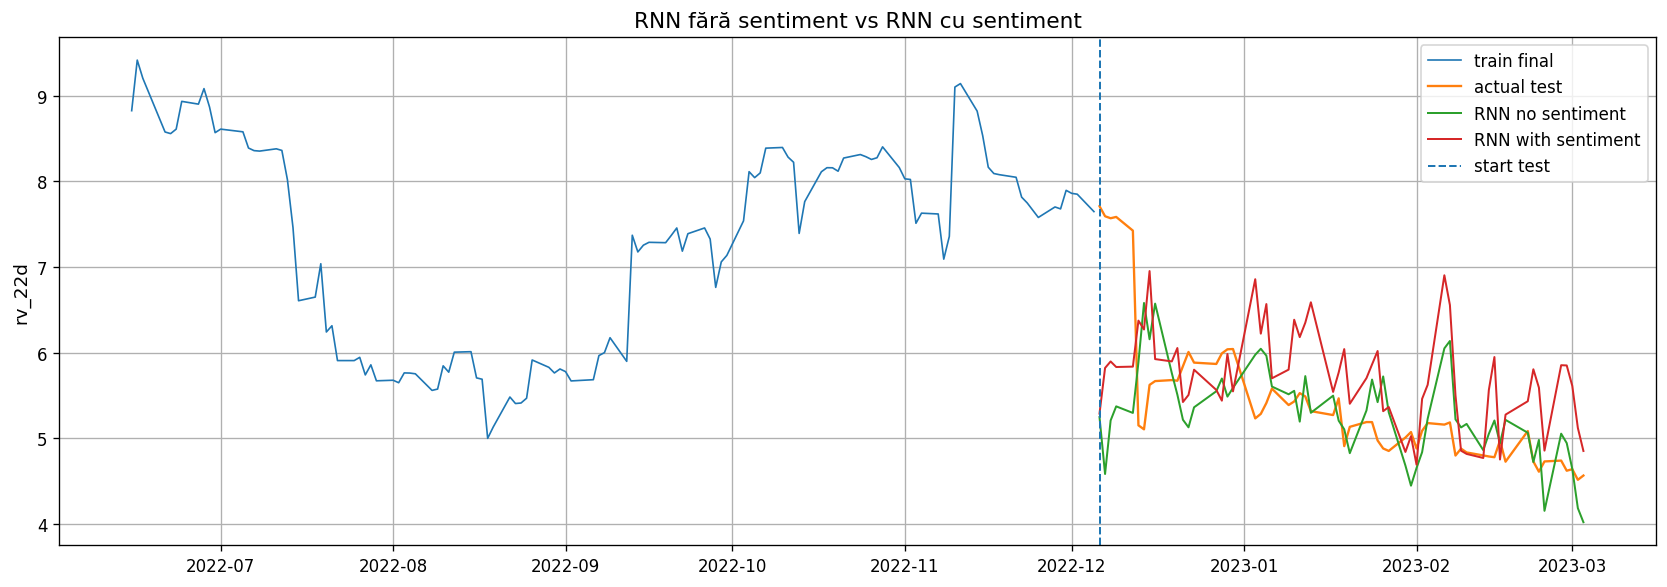

In [26]:
# ------------------------------------------------------------
# 11.3 FIT RNN MODELS
# ------------------------------------------------------------

if TF_OK:
    # RNN fără sentiment
    rnn_no_model, rnn_no_hist, rnn_no_pred_arr = fit_deep_model(
        X_no_train_s, y_train_seq_s, X_no_test_s, model_type='RNN'
    )
    rnn_no_pred = pd.Series(
        np.asarray(rnn_no_pred_arr, dtype=float).reshape(-1),
        index=idx_test_seq,
        name='RNN no sentiment'
    ).clip(lower=0)

    # RNN cu sentiment
    rnn_sent_model, rnn_sent_hist, rnn_sent_pred_arr = fit_deep_model(
        X_sent_train_s, y_train_seq_s, X_sent_test_s, model_type='RNN'
    )
    rnn_sent_pred = pd.Series(
        np.asarray(rnn_sent_pred_arr, dtype=float).reshape(-1),
        index=idx_test_seq,
        name='RNN with sentiment'
    ).clip(lower=0)

    predictions['RNN no sentiment'] = rnn_no_pred
    predictions['RNN with sentiment'] = rnn_sent_pred

    all_results.append(evaluate_model('RNN no sentiment', y_test_seq_series, rnn_no_pred, 'RNN', uses_sentiment=False))
    all_results.append(evaluate_model('RNN with sentiment', y_test_seq_series, rnn_sent_pred, 'RNN', uses_sentiment=True))

    plot_prediction(
        y_train_seq_series,
        y_test_seq_series,
        {'RNN no sentiment': rnn_no_pred, 'RNN with sentiment': rnn_sent_pred},
        title='RNN fără sentiment vs RNN cu sentiment',
        filename='09_rnn_no_sent_vs_sent.png'
    )
else:
    print('RNN skipped — TensorFlow unavailable.')


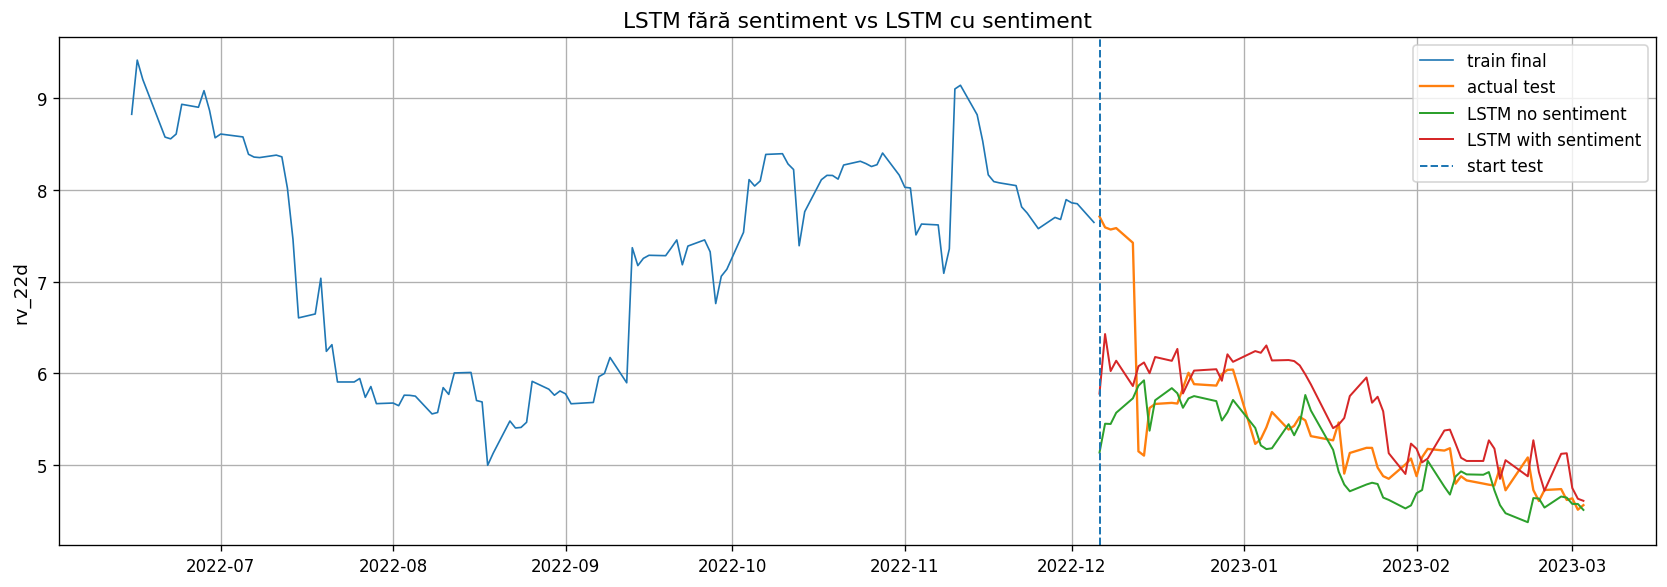

In [27]:
# ------------------------------------------------------------
# 11.4 FIT LSTM MODELS
# ------------------------------------------------------------

if TF_OK:
    # LSTM fără sentiment
    lstm_no_model, lstm_no_hist, lstm_no_pred_arr = fit_deep_model(
        X_no_train_s, y_train_seq_s, X_no_test_s, model_type='LSTM'
    )
    lstm_no_pred = pd.Series(
        np.asarray(lstm_no_pred_arr, dtype=float).reshape(-1),
        index=idx_test_seq,
        name='LSTM no sentiment'
    ).clip(lower=0)

    # LSTM cu sentiment
    lstm_sent_model, lstm_sent_hist, lstm_sent_pred_arr = fit_deep_model(
        X_sent_train_s, y_train_seq_s, X_sent_test_s, model_type='LSTM'
    )
    lstm_sent_pred = pd.Series(
        np.asarray(lstm_sent_pred_arr, dtype=float).reshape(-1),
        index=idx_test_seq,
        name='LSTM with sentiment'
    ).clip(lower=0)

    predictions['LSTM no sentiment'] = lstm_no_pred
    predictions['LSTM with sentiment'] = lstm_sent_pred

    all_results.append(evaluate_model('LSTM no sentiment', y_test_seq_series, lstm_no_pred, 'LSTM', uses_sentiment=False))
    all_results.append(evaluate_model('LSTM with sentiment', y_test_seq_series, lstm_sent_pred, 'LSTM', uses_sentiment=True))

    plot_prediction(
        y_train_seq_series,
        y_test_seq_series,
        {'LSTM no sentiment': lstm_no_pred, 'LSTM with sentiment': lstm_sent_pred},
        title='LSTM fără sentiment vs LSTM cu sentiment',
        filename='10_lstm_no_sent_vs_sent.png'
    )
else:
    print('LSTM skipped — TensorFlow unavailable.')


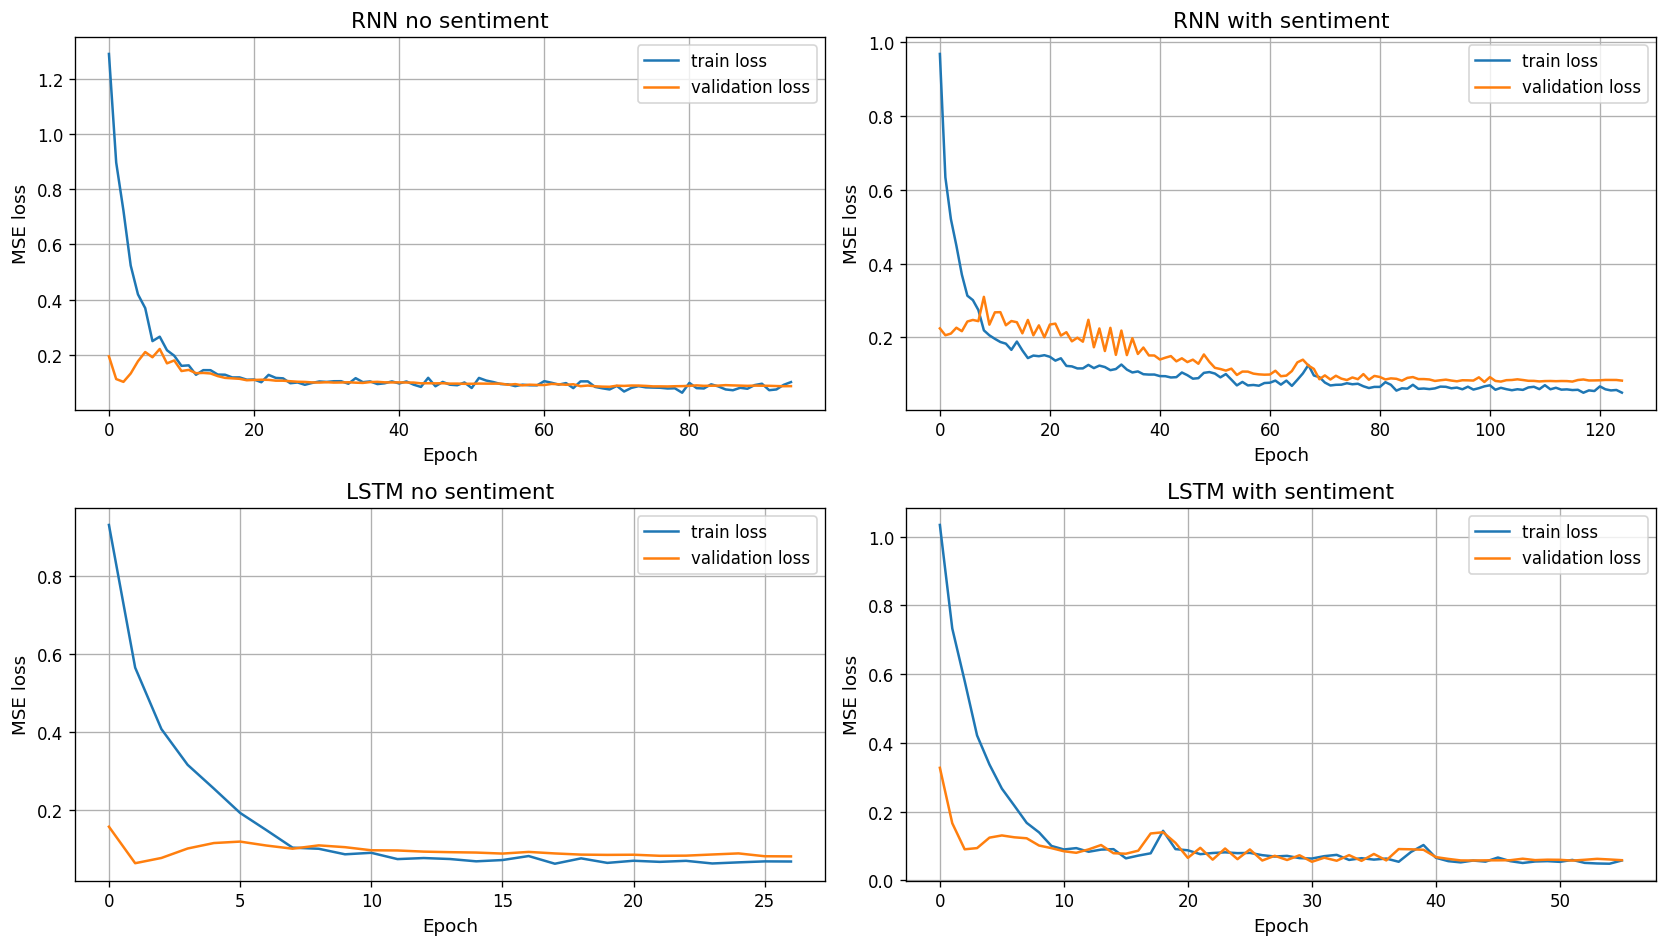

RNN no sentiment: epochs actually trained = 95
RNN with sentiment: epochs actually trained = 125
LSTM no sentiment: epochs actually trained = 27
LSTM with sentiment: epochs actually trained = 56


In [28]:
# ------------------------------------------------------------
# 11.5 TRAINING / VALIDATION LOSS CURVES
# ------------------------------------------------------------

if TF_OK:
    histories = {
        'RNN no sentiment': rnn_no_hist if 'rnn_no_hist' in globals() else None,
        'RNN with sentiment': rnn_sent_hist if 'rnn_sent_hist' in globals() else None,
        'LSTM no sentiment': lstm_no_hist if 'lstm_no_hist' in globals() else None,
        'LSTM with sentiment': lstm_sent_hist if 'lstm_sent_hist' in globals() else None,
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.ravel()

    for ax, (name, hist) in zip(axes, histories.items()):
        if hist is None:
            ax.axis('off')
            continue
        ax.plot(hist.history.get('loss', []), label='train loss')
        ax.plot(hist.history.get('val_loss', []), label='validation loss')
        ax.set_title(name)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE loss')
        ax.legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / '11_deep_learning_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    for name, hist in histories.items():
        if hist is not None:
            print(f'{name}: epochs actually trained = {len(hist.history.get("loss", []))}')
else:
    print('Loss curves skipped — TensorFlow unavailable.')


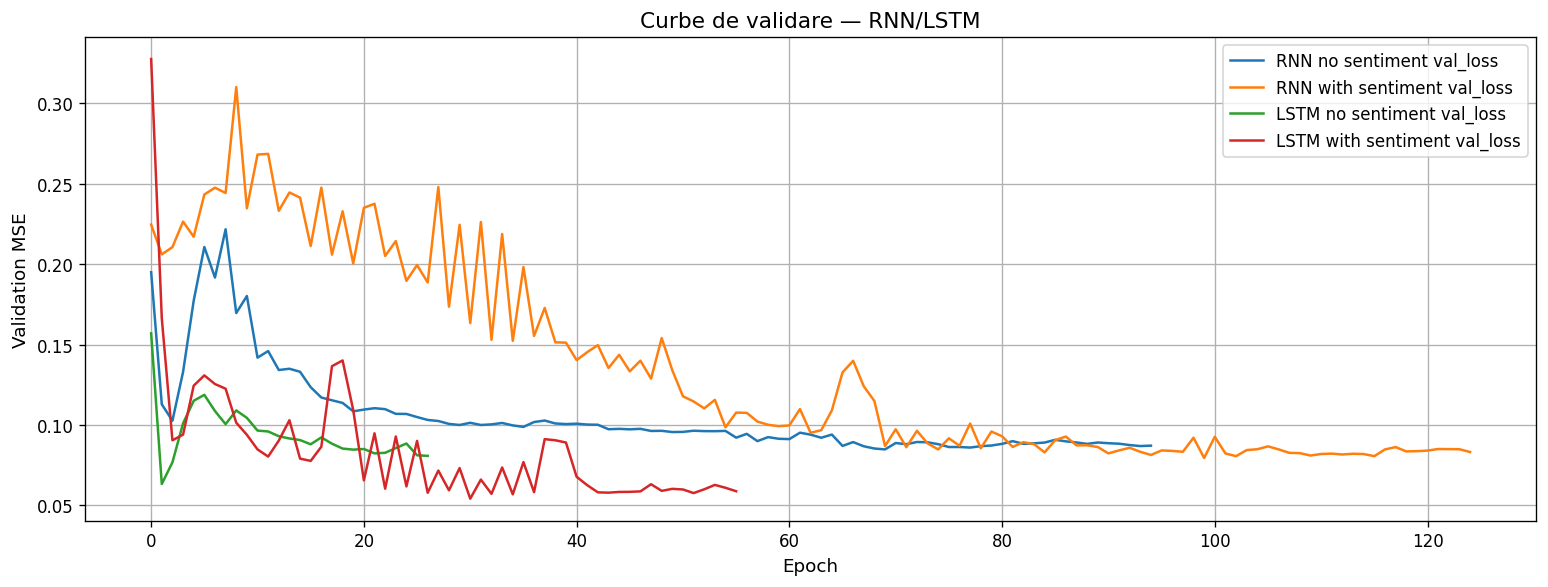

In [29]:
# ------------------------------------------------------------
# 11.5 TRAINING CURVES FOR DEEP MODELS
# ------------------------------------------------------------

if TF_OK:
    histories = {}
    if 'rnn_no_hist' in globals(): histories['RNN no sentiment'] = rnn_no_hist
    if 'rnn_sent_hist' in globals(): histories['RNN with sentiment'] = rnn_sent_hist
    if 'lstm_no_hist' in globals(): histories['LSTM no sentiment'] = lstm_no_hist
    if 'lstm_sent_hist' in globals(): histories['LSTM with sentiment'] = lstm_sent_hist

    if len(histories) > 0:
        fig, ax = plt.subplots(figsize=(13, 5))
        for name, hist in histories.items():
            ax.plot(hist.history['val_loss'], label=f'{name} val_loss')
        ax.set_title('Curbe de validare — RNN/LSTM')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation MSE')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / '11_deep_learning_validation_curves.png', dpi=150, bbox_inches='tight')
        plt.show()

## 12. Comparație finală și Diebold-Mariano

Comparam modelele pe aceeași țintă: `rv_22d`.

Important: interpretarea principală este dacă modelele cu sentiment îmbunătățesc acuratețea față de variantele fără sentiment.

In [30]:
# ------------------------------------------------------------
# 12. FINAL RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame(all_results)
if len(results_df) > 0:
    results_df = results_df.sort_values('RMSE').reset_index(drop=True)
    results_df.to_csv(TABLE_DIR / '05_final_model_comparison_rv22d.csv', index=False)
    display(results_df.round(6))
else:
    print('No results collected.')

,model,family,uses_sentiment,target,n_test,MAE,RMSE,MAPE,R2,QLIKE_RV2
0,VAR multivariate,VAR,True,rv_22d,522,0.140717,0.221563,3.838520,0.956875,3.624651
1,HAR-RV-X,HAR-RV-X,True,rv_22d,515,0.140519,0.223940,3.859810,0.947177,3.604855
2,HAR-RV,HAR-RV,False,rv_22d,515,0.139482,0.224152,3.816922,0.947077,3.604809
3,MLP no sentiment,MLP,False,rv_22d,515,0.213264,0.307585,5.530538,0.900348,3.609528
4,LSTM with sentiment,LSTM,True,rv_22d,519,0.427263,0.554458,11.477638,0.708388,3.651511
5,LSTM no sentiment,LSTM,False,rv_22d,519,0.415299,0.559800,10.923890,0.702742,3.651620
6,MLP with sentiment,MLP,True,rv_22d,515,0.441761,0.572083,12.348678,0.655273,3.638914
7,RNN no sentiment,RNN,False,rv_22d,519,0.498559,0.617362,13.873822,0.638467,3.654275
8,RNN with sentiment,RNN,True,rv_22d,519,0.576663,0.720094,15.751317,0.508134,3.668795


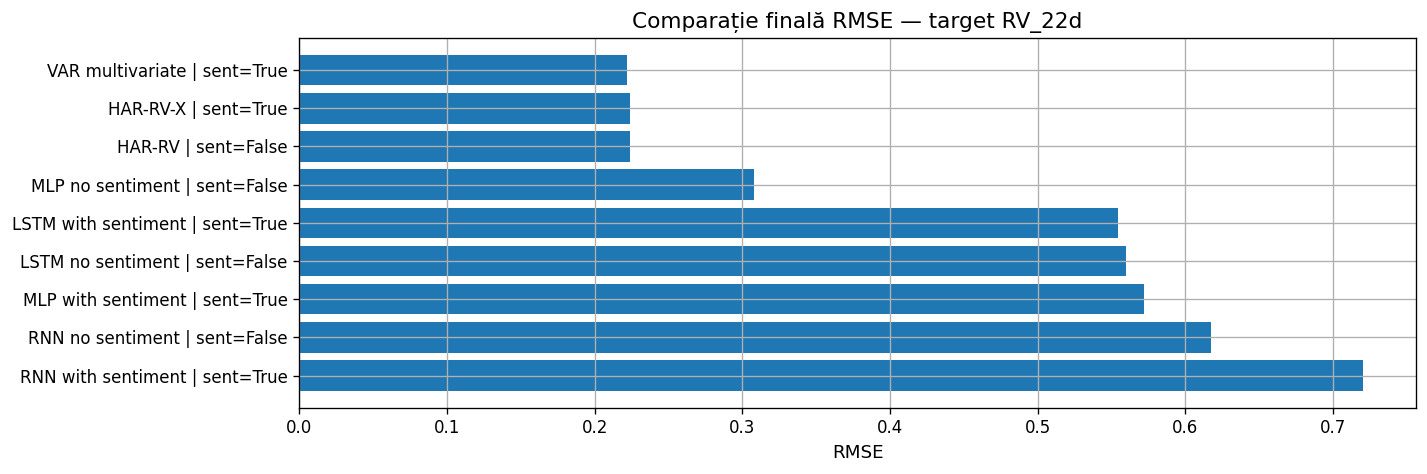

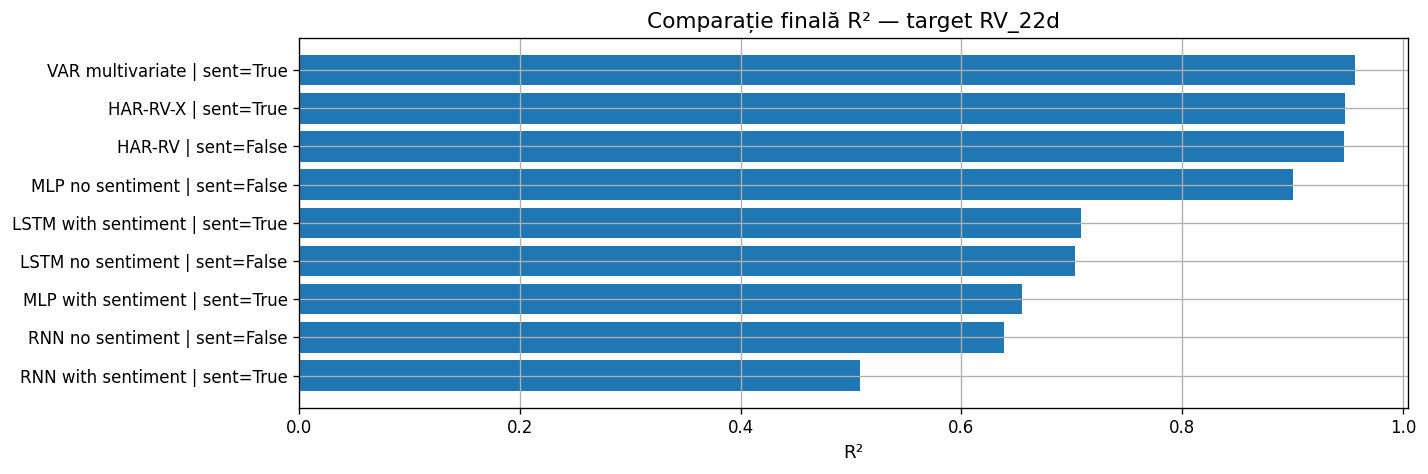

In [31]:
# ------------------------------------------------------------
# 12.1 FINAL COMPARISON PLOT
# ------------------------------------------------------------

if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(results_df))))
    plot_df = results_df.sort_values('RMSE')
    labels = plot_df['model'] + ' | sent=' + plot_df['uses_sentiment'].astype(str)
    ax.barh(labels, plot_df['RMSE'])
    ax.set_title('Comparație finală RMSE — target RV_22d')
    ax.set_xlabel('RMSE')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '12_final_rmse_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(results_df))))
    plot_df = results_df.sort_values('R2', ascending=False)
    labels = plot_df['model'] + ' | sent=' + plot_df['uses_sentiment'].astype(str)
    ax.barh(labels, plot_df['R2'])
    ax.set_title('Comparație finală R² — target RV_22d')
    ax.set_xlabel('R²')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '13_final_r2_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

### Testul Diebold-Mariano

Comparații principale:

- HAR-RV-X vs HAR-RV;
- MLP cu sentiment vs MLP fără sentiment;
- RNN cu sentiment vs RNN fără sentiment;
- LSTM cu sentiment vs LSTM fără sentiment.

In [32]:
# ------------------------------------------------------------
# 12.2 DIEBOLD-MARIANO TESTS
# ------------------------------------------------------------

def diebold_mariano(y_true, pred_1, pred_2, loss='squared'):
    y_true = pd.Series(y_true).dropna()
    pred_1 = pd.Series(pred_1).dropna()
    pred_2 = pd.Series(pred_2).dropna()
    idx = y_true.index.intersection(pred_1.index).intersection(pred_2.index)
    y = y_true.loc[idx]
    p1 = pred_1.loc[idx]
    p2 = pred_2.loc[idx]

    e1 = y - p1
    e2 = y - p2
    if loss == 'squared':
        d = e1**2 - e2**2
    elif loss == 'absolute':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError('loss must be squared or absolute')

    d = d.dropna()
    n = len(d)
    if n < 5 or d.std(ddof=1) == 0:
        return {'DM_stat': np.nan, 'p_value': np.nan, 'n': n, 'mean_loss_diff': np.nan}

    dm_stat = d.mean() / np.sqrt(d.var(ddof=1) / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return {'DM_stat': dm_stat, 'p_value': p_value, 'n': n, 'mean_loss_diff': d.mean()}

# Target series pentru fiecare familie poate avea index diferit; folosim predicțiile ca ghid.
dm_rows = []
comparisons = [
    ('HAR-RV-X', 'HAR-RV', har_test[TARGET] if 'har_test' in globals() else None),
    ('MLP with sentiment', 'MLP no sentiment', ml_test[TARGET] if 'ml_test' in globals() else None),
]
if TF_OK and 'y_test_seq_series' in globals():
    comparisons += [
        ('RNN with sentiment', 'RNN no sentiment', y_test_seq_series),
        ('LSTM with sentiment', 'LSTM no sentiment', y_test_seq_series),
    ]

for m1, m2, y in comparisons:
    if y is not None and m1 in predictions and m2 in predictions:
        res = diebold_mariano(y, predictions[m1], predictions[m2], loss='squared')
        res.update({'model_1': m1, 'model_2': m2, 'loss': 'squared'})
        dm_rows.append(res)

dm_df = pd.DataFrame(dm_rows)
if len(dm_df) > 0:
    dm_df['decision_5pct'] = np.where(dm_df['p_value'] < 0.05, 'different predictive accuracy', 'no significant difference')
    dm_df.to_csv(TABLE_DIR / '06_diebold_mariano_tests.csv', index=False)
    display(dm_df.round(6))
else:
    print('No DM comparisons available.')


,DM_stat,p_value,n,mean_loss_diff,model_1,model_2,loss,decision_5pct
0,-0.228721,0.819086,515,-0.000095,HAR-RV-X,HAR-RV,squared,no significant difference
1,10.502355,0.000000,515,0.232671,MLP with sentiment,MLP no sentiment,squared,different predictive accuracy
2,4.741232,0.000002,519,0.137400,RNN with sentiment,RNN no sentiment,squared,different predictive accuracy
3,-0.222277,0.824098,519,-0.005952,LSTM with sentiment,LSTM no sentiment,squared,no significant difference


## 13. Sumar automat pentru interpretare

Această secțiune extrage rezultatele principale pentru a fi discutate în raport.

In [33]:
# ------------------------------------------------------------
# 13. AUTOMATIC SUMMARY
# ------------------------------------------------------------

print('================ NOTEBOOK 03 SUMMARY ================')
print(f'Target principal: {TARGET}')
print(f'Perioadă: {analysis_df.index.min().date()} → {analysis_df.index.max().date()} | n={len(analysis_df):,}')
print(f'Train/Test split: {SPLIT_RATIO:.0%}/{1-SPLIT_RATIO:.0%}')

print('\n--- Variabile sentiment folosite ---')
print(preferred_sentiment_cols)

print('\n--- VAR ---')
print('VAR columns:', var_cols if 'var_cols' in globals() else 'not available')
print('Selected lag:', selected_lag if 'selected_lag' in globals() else 'not available')
print('VAR stable:', var_fit.is_stable(verbose=False) if 'var_fit' in globals() else 'not available')

if 'granger_df' in globals() and len(granger_df) > 0:
    print('\n--- Granger significant at 5% ---')
    sig_granger = granger_df[granger_df['pvalue'] < 0.05]
    if len(sig_granger) > 0:
        print(sig_granger[['caused', 'causing', 'pvalue']].to_string(index=False))
    else:
        print('No significant Granger causality at 5%.')

if len(results_df) > 0:
    print('\n--- Best model by RMSE ---')
    print(results_df.iloc[0][['model', 'family', 'uses_sentiment', 'RMSE', 'MAE', 'R2']].to_string())

    print('\n--- Best model WITH sentiment by RMSE ---')
    sent_models = results_df[results_df['uses_sentiment'] == True]
    if len(sent_models) > 0:
        print(sent_models.iloc[0][['model', 'family', 'RMSE', 'MAE', 'R2']].to_string())
    else:
        print('No sentiment models available.')

    print('\n--- Best model WITHOUT sentiment by RMSE ---')
    nosent_models = results_df[results_df['uses_sentiment'] == False]
    if len(nosent_models) > 0:
        print(nosent_models.iloc[0][['model', 'family', 'RMSE', 'MAE', 'R2']].to_string())
    else:
        print('No non-sentiment models available.')

print('\nTabele salvate în:', TABLE_DIR)
print('Grafice salvate în:', FIG_DIR)

================ NOTEBOOK 03 SUMMARY ================
Target principal: rv_22d
Perioadă: 2018-02-02 → 2024-12-30 | n=1,738
Train/Test split: 70%/30%

--- Variabile sentiment folosite ---
['S_polarity', 'S_mean', 'S_sum', 'neg_share', 'pos_share', 'n_articles']

--- VAR ---
VAR columns: ['rv_22d', 'r_t', 'vix', 'S_polarity', 'neg_share', 'S_mean']
Selected lag: 1
VAR stable: True

--- Granger significant at 5% ---
caused causing       pvalue
rv_22d     vix 6.201812e-30

--- Best model by RMSE ---
model             VAR multivariate
family                         VAR
uses_sentiment                True
RMSE                      0.221563
MAE                       0.140717
R2                        0.956875

--- Best model WITH sentiment by RMSE ---
model     VAR multivariate
family                 VAR
RMSE              0.221563
MAE               0.140717
R2                0.956875

--- Best model WITHOUT sentiment by RMSE ---
model       HAR-RV
family      HAR-RV
RMSE      0.224152
MAE     

## Concluzii de completat după rulare

După rulare, vom interpreta:

1. dacă sentimentul Granger-cauzează volatilitatea;
2. dacă IRF indică reacția volatilității la șocuri de sentiment;
3. dacă modelele cu sentiment bat variantele fără sentiment;
4. dacă MLP/RNN/LSTM aduc îmbunătățiri față de HAR-RV / VAR;
5. dacă Diebold-Mariano confirmă diferențe semnificative;
6. care model devine modelul final de prognoză pentru volatilitatea S&P 500.